# 10장 신경망 알고리즘 기초

세 번째 모듈에 오신 것을 환영합니다. 이번 모듈에서는 신경망 알고리즘 혹은 딥러닝 알고리즘을 활용한 언어 모델과 그것들에 기반한 텍스트 분석을 공부할 것입니다. 사실 요즘 NLP라고 하면 많은 이들이 딥러닝에 기반한 모델과 서비스를 떠올립니다. 원칙적으로 딥러닝은 NLP의 일부만을 차지하는 것을 고려하면, 딥러닝 알고리즘을 자연어를 대상으로 활용한 여러 기술이 사람들에게 얼마나 깊은 인상을 남겼는지 알 수 있습니다. 이번 모듈에서는 딥러닝 알고리즘, 좀 더 넓게 봐서 신경망 알고리즘의 기초를 배우고, 그것이 자연어 처리의 다양한 과제에 어떻게 적용되는지 살펴본 후, 현재의 언어 AI 세계를 열어젖힌 트랜스포머 아키텍쳐와 self-attention에 대해 알아볼 것입니다. 그리고 이번 모듈 첫번째 시간인 오늘은 신경망 알고리즘이 무엇이고 뭘 할 수 있는지 알아볼 것입니다. 

## 1. 머신 러닝과 신경망 알고리즘

신경망 알고리즘은 무엇일까요? 일단 '알고리즘'이라는 단어가 들어가는 것을 보아 무언가를 하는 작업 절차임을 알 수 있습니다. 알고리즘(Algorithm)은 기본적으로 '특정한 과제를 해내기 위한 명확한 순차적 절차'를 의미합니다. 최근 알고리즘이라는 단어가 마치 여러 플랫폼 기업의 추천 시스템을 의미하는 말로 사용되는 경우가 많은데, 엄밀히 보면 알고리즘은 그보다 훨씬 일반적인 개념입니다. 그래서 여러분이 '알고리즘'이라는 이름이 포함된 수업을 들으면, 추천이라는 과제와 전혀 상관없는 것들, 예를 들어 생각지 못하게 '최단거리탐색 알고리즘'이라거나, '정렬 알고리즘' 따위를 배우게 됩니다. 즉 알고리즘은 본질적으로 작업 절차를 의미하고, '과제'가 무엇이냐에 따라 그 형태가 매우 다릅니다. 

그러면 신경망 알고리즘이 해결하고자 하는 과제는 무엇일까요? 즉 그것은 무엇을 위한 작업 절차일까요? 기본적으로 신경망 알고리즘은  입력과 출력 사이의 패턴을 파악하는 것을 목적으로 합니다. 즉 어떤 입력 데이터와 출력 데이터가 주어졌을 때, 그 둘 사이에 존재하는 연결 패턴을 파악하여, 이러저러한 입력이 들어가면 이러저러한 출력이 나온다는 규칙을 추정합니다. 이처럼 데이터에 존재하는 입력과 출력 사이에 존재하는 규칙을 알아낸다는 면에서 '학습' 알고리즘이라 불리기도 하고, 입력과 출력 사이에 존재하는 함수를 근사하는 과정이라고 여겨지기도 합니다. 

입력과 출력 사이의 패턴을 파악한다고 하니 좀 추상적으로 여겨지실 것 같습니다. 그런데 사실 이건 우리 인간이 명시적으로 때로는 무의식적으로 하는 일입니다. 좀 더 구체적인 예를 들어봅시다. 

1. 주식 가격 설명/예측: 우리가 주식 거래로 돈을 벌고 싶다고 하죠. 그러면 '미래의 주가'를 알아내야 할 것입니다. 이를 위한 가장 정석적인 방식은, 과거의 데이터에서 주가에 영향을 미칠 법한 여러 요인들이 주가에 어떻게 영향을 미쳤는지 파악하는 것입니다. 기업의 재무 상태나 바로 전 시기 주가 혹은 전체 주식 시장의 상황이 특정 주가에 반영되는 방식을 학습하는 것이죠. 이건 '재무 상태', '과거 주가', '전체 시장 상황'이라는 입력과 '주가'라는 출력을 연결하는 패턴을 파악하는 것입니다. 그리고 그 패턴에 기반하여 미래의 주가를 예측하고, 그에 기반하여 행동합니다. 

2. 기대 여명 설명/예측: 많은 이들이 자기 자신을 포함하여 어떤 사람이 얼마나 더 살 수 있을지 알아내고 싶어합니다. 그리고 남은 수명은 여러 요인에 영향을 받는다고 알려져 있죠. 나이, 소득, 계층, 주거지, 국적 등 다양한 것들이 영향을 미칩니다. 마찬가지로 우리는 기존의 데이터에서 이런 입력값들과 (나이, 소득, 계층, 주거지, 국적) 출력값 (수명) 사이의 연결을 파악합니다. 그리고 그것에 기반하여 나 혹은 어떤 사람의 수명을 예상합니다. 

3. 리뷰의 정서 분류: 우리가 음식점을 창업해서 운영하고 있다고 합시다. 우리 음식점 페이지에 남겨지는 리뷰에 주목하는 것은 중요한 일이죠. 가장 기본적으로 리뷰가 긍정적인 태도를 담고 있는지, 아니면 부정적인 태도를 담고 있는지 구분하고 싶다고 합시다. 이게 생각보다 아주 쉽지는 않습니다. 예를 들어 처음에는 'ㅠㅠ'라는 이모티콘이 있으면 '부정'이라고 쉽게 해석할 수 있을 듯하지만, '사장님의 친절에 눈물이 ㅠㅠ' 라는 말은 긍정에 가깝죠. 그래서 기존에 남겨진 리뷰를 보면서 무엇이 긍정에 해당하는지, 무엇이 부정에 해당하는지 그 패턴을 파악합니다. 즉 '사용 단어, 순서, 이모티콘이나 이모지와의 조합 방식' 같은 입력을 두 가지 종류의 출력값 '긍정이냐 부정이냐'와 연결하는 규칙을 찾아내는 거죠.   


신경망 알고리즘은, 우리가 인간의 종합적 인지 능력을 활용하여 무의식적으로 해내는 이 입력/출력 사이의 패턴 파악을 컴퓨터의 계산 절차를 통해 해내는 작업 절차입니다. 엄밀히 말하면 이처럼 입출력 사이의 패턴을 찾아내는 알고리즘이 많으니까 (예를 들어 선형 회귀, Support Vector Machine 등이 그것들입니다), 그걸 해내는 여러 작업 절차 중 하나라고 할 수 있지요. 그럼 신경망 알고리즘처럼 이런 패턴 인식을 컴퓨터를 활용한 계산 절차를 통해 해내면 뭐가 좋은 걸까요? 여러 가지가 좋지만, 두 가지 점이 특히 중요합니다. 

1. 과거의 입력 데이터가 아니라 미지의 입력 데이터에 기반하여 우리가 관심있는 출력값을 예측할 수 있습니다. 신경망 알고리즘을 통해 입력과 출력 사이에 존재하는 패턴 혹은 함수를 찾아내면, 거기에 새로운 입력값을 넣을 수 있습니다. 앞서 말한 것처럼 과거에 기업 재무 상태와 여러 요인이 주가에 미치는 영향 패턴을 파악하면, 지금의 정보에 기반하여 향후 그 기업의 주가가 어떠할지 예측할 수 있는 것처럼 말이지요. 

2. 패턴의 인식과 그것의 적용이라는 작업을 인간이 수행하는게 아니라 컴퓨터에 기반한 인공물 (computational artifact), 쉽게 말해 기계에게 시킬 수 있습니다. 인간은 이런 입력/출력 사이의 패턴 매칭을 잘 합니다. 하지만 이건 힘이 들고 스트레스가 발생하는 일입니다. 패턴을 잘 인지했다고 하더라도, 그 패턴을 활용해 출력을 만드는 일도 늘 쉬운 일은 아닙니다. 아주아주 간단한 무의식적 작업도, 그게 많이 반복되면 힘듭니다. 예를 들어 우리는 개 사진을 보면 거의 무의식적으로 패턴을 파악해서 '개'라고 분류합니다. 아주 쉽죠. 그런데 그런 작업을 10000장을 대상으로 하면 어떨까요? 아무리 쉬운 일도, 너무 많이 하면 힘듭니다. 그런데 기계가 패턴도 인식하고 미지의 입력을 받아 출력도 만들어내면, 그건 기존에 인간이 하던 일을 대체하는 효과가 발생합니다. 

여기에 한가지만 더하자면, 연구자인 제 입장에서는 입력과 출력 사이의 패턴이 무엇인지 '연구'하는 관점에서도 유용한 면이 있다는 점을 언급하고 싶습니다. 즉 

3. 신경망 알고리즘이 포착한 패턴 그 자체를 분석함으로써, 입력과 출력 사이의 관계를 잘 이해할 수 있습니다. 예를 들어 포착된 패턴에서 출력에 가장 큰 영향을 미치는 입력 요인이 무엇인지, 중요 요인들이 어떤 구조와 변환을 통해 출력으로 이어지는지 등을 살펴보는 것입니다. 이건 우리가 연구에서 전통적으로 관심을 가진 활동인 '데이터에서 우리가 잘 몰랐던 패턴을 발견'하려는 목적과 닿아 있습니다. 

하지만 마지막 사항은 신경망 알고리즘처럼 파라미터가 매우 많은 모델에 기대어 이 작업을 하는 경우, 매우 많은 후처리가 있어야 가능한 경우가 많습니다. 이와 관련된 많은 개발이 진행되고 있지만, 논쟁도 많은 편이죠. 그래서 일반적으로 많이 활용되는 방식은 아닌 듯하고, 모델의 해체 및 재조립을 자유자재로 수행하는 연구자들 일부가 수행하고 있는 듯한 인상입니다 ^^;; 하지만 우리도 사실 할 수 있습니다. 늘 그렇듯, 알고보면 다 할만한 일이거든요. 그래서 이 수업에서는 그 단초를 조금은 살펴볼 것입니다. 

요컨대 신경망 알고리즘은 많은 경우 (1) 기존의 데이터에서 여러 종류의 입력과 출력 사이의 패턴을 알아내서, (2) 학습된 패턴에 기반하여 미지의 입력 데이터를 출력으로 연결하는 일을 합니다. 이것이 아주 높은 완성도로 이루어지면 (예를 들어 기계도 인간처럼 사진을 보고 이게 개 사진 인지 고양이 사진인지 기가 막히게 분류하면), 인간이 피곤해하던 일을 기계에게 대신해서 시킬 수 있는 가능성이 열립니다. 그런데 신경망 알고리즘이 이걸 최근에 무척 높은 완성도로 해내기 시작하였고, 그래서 여러 영역에서 활용되고 있는 거죠. 

보통 이런 신경망 알고리즘을 머신 러닝 알고리즘의 일종이라고 설명합니다. 머신러닝, 즉 기계가 학습한다는 일의 정의는 다양할 수 있습니다만, 가장 고전적인 정의는 다음과 같습니다. Tom Mitchell 이라는 분이 [Machine Learning]이라는 본인의 책에서 내렸던 정의죠. 

    A computer program is said to learn from experience E with respect to some class of tasks T and performance measure P, if its performance at tasks in T, as measured by P, improves with experience E.
    
즉 컴퓨터 프로그램이 학습한다 함은, 데이터를 통한 경험이 늘어남에 따라 특정 과제의 수행 성과가 계속 좋아지는 것을 의미합니다. 그리고 이는 신경망 알고리즘을 통한 학습을 정확히 설명하고 있습니다. 신경망 알고리즘은 컴퓨터 프로그램이 데이터에서 입력과 출력 사이의 패턴을 찾아내는 일을 해내려고 합니다. 그게 이 알고리즘이 해내려는 T, task죠. 이것이 데이터, E가 많아질 수록 더 잘 됩니다. 이 '잘된다'는 기준은 loss나 accuracy, RMSE 같은 특정한 수치적 지표로 측정됩니다. 이게 P인 셈입니다. 

다만 한 가지 주의할 점은, '주어진 데이터의 입력과 출력 사이의 패턴을 잘 알아내는 것'과 '그 패턴을 미지의 데이터에 적용하여 성공적인 출력값을 예측하는 것'이 늘 정비례하지 않는다는 것입니다. 소위 '과적합'(overfitting)의 문제가 있기 때문에, 데이터에서 입출력 사이의 패턴을 과도하게 정교하게 알아내면 미지의 데이터에서 성공율이 오히려 떨어지는 현상이 생기곤 합니다. 이런 현상의 원인을 아주 간단히 설명하면, 데이터에는 정보와 더불어 소음도 존재하기 때문입니다. 즉 데이터 = 정보 + 소음인 셈이죠. 그런데 기계가 학습 과정을 통해 그 소음까지 학습해버리면, 미지의 데이터에서는 성능이 떨어지는 것이지요. 신경망 알고리즘의 적용 과정에서도 당연히 이런 현상이 나타날 수 있고, 나중에 배우겠지만 이를 극복하기 위한 다양한 방법이 있습니다. 

교과서적으로 설명하자면 이런 머신러닝에는 여러 종류가 있습니다. 지도학습/비지도학습/강화학습이 전형적이고 대표적인 분류방법입니다. 각각을 간단히 설명하자면, 지도학습은 우리가 앞서 든 예처럼 출력값 혹은 응답 변수가 명확하고, 그것을 잘 예측하고 분류하는 것을 목적으로 기계를 학습시키는 방식을 뜻합니다. 이제까지 등장한 예는 모두 지도학습의 예라고 할 수 있습니다. 비지도학습은 반대로 출력값 혹은 응답변수 없이, 그저 데이터에 존재하는 구조적 패턴이나 특징을 포착하는 것을 목적으로 기계를 학습시키는 것입니다. 예를 들어 데이터를 보고 비슷한 케이스들끼리 묶어준다거나 하는 클러스터링이 대표적이죠. 우리가 앞선 모듈에서 배운 LDA나 네트워크 과학의 community detection algorithm 등도 좋은 예입니다. 강화학습은 에이전트가 환경 안에서 행동하면서 보상에 기반하여 학습하는 방식입니다. 입력과 출력이 있기는 한데, 지도학습과는 좀 다른 방식으로 존재합니다. 예를 들어 바둑에서는 매 수마다 정답이 주어지지 않습니다. 승리냐 패배냐라는 보상은 게임이 모두 끝나야 주어집니다. 이런 환경에서 보상을 최대화하는 방향으로 전략을 찾아가는 것이 강화학습입니다.

신경망 알고리즘도 원리적으로는 여러 가지 방식의 학습을 위해 활용될 수 있습니다. 하지만 우리는 그 중 가장 많이 활용되는 방식인 지도학습을 위해 신경망 알고리즘을 활용하는 것에 대해 공부하겠습니다. 각종 언어 모델 또한 크게 보아 이 지도학습을 활용해서 만들어지는 경우가 대부분이고, 무엇보다 지도학습 상황에서 활용법을 잘 이해하면, 다른 활용도 쉽게 이해할 수 있거든요. 

## 2. 퍼셉트론과 신경망 알고리즘

자 그럼 신경망 알고리즘에 대해 배워봅시다. 앞서 신경망 알고리즘이 입력과 출력 사이의 패턴을 포착한다고 했습니다. 구체적으로 이걸 어떻게 하는 것일까요? 여기서 '신경망'이라는 키워드에 주목해야 합니다. 신경망은 Neural Network를 번역한 말인데요, 인간의 신경 세포가 네트워크를 형성하여 정보를 처리하고 학습을 하는데, 이를 지칭하는 말입니다. 즉 신경망 알고리즘은 인간의 신경 세포, 즉 뉴런 다발이 정보를 처리하고 패턴을 학습하는 양상을 일정 부분 모방하고 있습니다. 정확히 말하자면, 발달이 거듭될 수록 인간의 신경망 작동과는 여러 면에서 멀어졌습니다만, 적어도 초기 아이디어는 꽤나 닮아 있습니다. 

신경망 알고리즘이 이처럼 뉴런의 정보 처리 형태와 꽤나 닮아있는 초기 형태였을 때에는 신경망 알고리즘이라 불리지도 않았습니다. 그때 그것의 이름은 '퍼셉트론'이었습니다. Rosenblatt이라는 분이 제안하였다고 하네요. 이 퍼셉트론이 진화해서 신경망 알고리즘이 되었다고 보면 됩니다. 그러면 퍼셉트론은 어떤 것이었을까요? 좀 딱딱하게 설명하자면, 퍼셉트론은 '입력 벡터 X와 가중치 w의 선형 결합에 임계값 (혹은 편향) b를 더한 뒤, 그 결과가 0 이상이면 1, 아니면 0을 출력하는 이진분류 모델'입니다. 수식으로 쓰자면 아래와 같죠. 

$$
\begin{aligned}
y=step(w^TX+b)
\end{aligned}
$$


사실 이보다는 예시를 보시는게 퍼셉트론을 이해하시기가 좋습니다. 아래의 그림을 보시죠. 


<div style="text-align:center;">
    <img src="_static/figures/퍼셉트론 이미지.jpg" width="500">
</div>


X1에 숫자가 하나 들어가서 w1이 곱해지고, x2에 숫자가 들어가서 w2가 곱해진 다음, 둘이 더해집니다. 그리고 여기에 상수가 다시 더해집니다. 그런 다음 이 숫자가 0보다 크면 결과가 1이 되고, 0보다 작으면 결과가 0이 됩니다. 매우 간단한데, 이것은 생각보다 많은 기능을 할 수 있습니다. 

예를 들어 이걸 가지고 'AND'라는 논리회로를 만든다고 해보죠. AND 논리회로는 무엇인가요? 그것은 둘 다 True여야 True가 되고, 하나라도 False가 생기면 False로 결과가 나오는 회로입니다. 일상어로도 쉽게 해볼 수 있는데, 두 개의 명제를 AND로 연결하면 둘 다 True여야 전체 문장이 True가 됩니다. '조원광은 초절정 미남이다'라는 명제와 '조원광은 남성이다'라는 명제를 AND로 이으면 '조원광은 초절정 미남이고 남성이다'라는 형태가 되죠. 그리고 이건 False입니다. False + True인 형태이기 때문입니다. 

이런 회로는 위의 퍼셉트론의 가중치와 편향을 조정해서 쉽게 만들 수 있습니다. 1이 True, 0이 False를 뜻한다고 해보죠. 그러면 X1과 X2에 (1,1)이 들어갈 때는 1이 나오고 그 경우를 제외하고는 모두 0이 나오도록 하는 w1, w2, b 값만 구하면 됩니다. 그리고 이런건 생각보다 많습니다^^ 예를 들어서 w1이 0.4, w2가 0.4, b가 -0.5인 경우를 생각해보죠. x1과 x2에 둘 다 1이 들어가야만 0을 넘게 됩니다. 

OR도 만들 수 있습니다. OR은 False + False 빼고는 다 True로 이어지는 논리회로입니다. 그래서 '조원광은 초절정 미남이거나 남성이다'라는 명제도 True가 됩니다. 뒤쪽 명제는 True니까요. 이런 기능을 하는 OR 회로는 w1 0.8, w2 0.8, b -0.5 정도로 설정하면 되겠네요. 그러면 둘 다 0이어야만 0이하의 값이 나올 것입니다. 즉 둘 다 False여야 False가 나오는 관계가 만들어지죠. 

여기서 두 가지 점을 집어봐야 합니다. 

- 첫 번째로, 퍼셉트론이 발달하여 나중에 '신경망' 알고리즘으로 불리는 이유는 짐작할 수 있습니다. 위의 그림을 보면, 우리가 중고등학교 시절 배운 뉴런의 메커니즘과 어느 정도 유사성이 있습니다. 인터넷에서 뉴런 이미지를 쉽게 찾아보실 수 있을텐데요, 인간의 뉴런 역시 여러 개의 수상돌기 (Dendrite) 로부터 정보를 받아서, 그것을 종합합니다. 외부에서 오는 신호의 강도가 일정 이상이 되면, 축삭 돌기 (axon)을 통해 신경 전달 물질을 방출함으로써 다른 뉴런에 정보를 전달합니다. 퍼셉트론은 이를 닮아 있습니다. x라는 입력 신호를 받아 자체 가중치를 가지고 정보를 종합하고, 그것이 0 이상일 경우에는 특별한 결과를 내놓는 식이니까요. 이 때문에 퍼셉트론을 계승한 신경망 알고리즘에 '신경망'이라는 글자가 들어가는 것입니다. 초기에 퍼셉트론이 제안되었을 때, 엄청난 관심을 받았다고 합니다. 아마도 이런 유사성 때문이 아니었을까 추측합니다. 

- 두 번째는 위와 같이 특정 기능을 하도록 하는 w와 b가 원리적으로 무수히 많다는 점입니다. AND회로와 OR 회로를 만족하는 w1/w2/b 세트는 무한히 많습니다. 그리고 그 중 하나를 임의로 생각해내는 것도 그리 어렵지 않습니다. 그럴 수 밖에 없습니다. 기하학적으로 생각해보면, 지금 과제는 간단한 분리 평면을 찾아내는 것이거든요. 아래의 그림을 봅시다.

<div style="text-align:center;">
    <img src="_static/figures/퍼셉트론 이미지2.jpg" width="400">
</div>

사실 지금 w1, w2, b를 고르는 작업은, 기하학적으로 보자면 그냥 저 그림의 점선과 같은 분할선을 찾아내는 것입니다. 왜냐하면 $x1 \times w1 + x2 \times w2 + b = 0$이라는 수식은 기하학적으로는 2차원 상의 선을 의미합니다. 이건 우리가 중/고등학교에서 배운 내용입니다. 그러면 $x1 \times w1 + x2 \times w2 + b > 0$ 은 뭘 뜻할까요? 그건 그 선 위의 공간을 의미합니다. 반대는 거꾸로고요. 그러면 AND나 OR 같은 회로는 그렇게 분할된 공간 한쪽에 무엇을 남겨두느냐는 문제로 바꿀 수 있습니다. 즉 AND에서는 (1,1)만 따로 분류가 되면 되고, OR에서는 (0,0)만 따로 분류가 되면 되죠. 즉 한쪽 공간에 남겨두면 된다는 말입니다. 당연히 이걸 해내는 선은 무수히 많습니다. 현재 주황색 점선은 AND 회로를 가능케 하는 무수한 선 중에 하나이고, 노란색 점선은 OR 회로를 가능케 하는 무수한 점선 중 하나입니다. 

물론 매 과제마다 대강 w1과 w2 그리고 b를 사람이 머리를 굴려 알아내는 것은 그리 좋은 방법이 아닐 것입니다. 그래서 퍼셉트론은 간단한 학습 알고리즘, 즉 w1,w2,b를 알아내는 처리 절차를 가지고 있었습니다. 간단히 설명하면 다음과 같습니다. 임의로 어떤 w와 b가 들어가 있다가, 이게 제대로 작동할 때에는 아무것도 하지 않고, 틀릴 때에는 아래와 같은 원칙으로 고칩니다. 

$$
\begin{aligned}
w &\leftarrow w + \eta(y_{true} - y_{pred})x \\
b &\leftarrow b + \eta(y_{true} - y_{pred})
\end{aligned}
$$

여기서 다른건 다 앞에 나왔었고, $\eta$는 학습률인데, 보통 0.1처럼 작은 값이 설정됩니다. 

이건 사실 매우 간단한 논리입니다. 어떤 데이터에 대해서 맞게 분류하고 있으면, w나 b나 손 댈 필요가 없습니다. 그런데 만약 틀린다면 어떨까요? 두 가지 경우가 있을 것입니다. 

- 정답이 1인데 0으로 모델이 예측한 경우: 이 경우는 WX+b가 기대보다 너무 작게 나온 것이죠. 0을 넘어서야 하는데 0을 넘어서지 못한 것이니까요. 그런 경우 w를 x 방향으로 증가시켜야 합니다. x가 마이너스 값이었을 경우에는 w는 거기에 곱해지는 값이니 좀 줄어야 할 것이고, x가 플러스일 경우에는 w는 늘어나야 할 것입니다. 그래야 전체 결과가 커질테니까요. b는 x에 상관없이 그냥 늘어나면 되겠네요. 
- 정답이 0인데 1로 모델이 예측한 경우: 이 경우는 거꾸로 기대보다 너무 크게 나온 것이죠. 그런 경우 w를 x방향으로 감소시킵니다. 논리는 완전히 동일합니다. b는 그냥 줄여야겠네요. 

사실 위의 도식은 이 두 가지 방향의 조정을 의미하고 있습니다. 기하학적으로 설명하자면, 일단 직선을 마음대로 그어놓고, 여러 데이터를 대입시켜보면서 오분류가 일어날 때마다 직선을 조금씩 조절하는 것이라고 보면 될 것입니다. 이렇게 하면, 우리가 위에서 임의로 대강 w와 b를 설정한 것과 같은 작업을 하지 않고, 데이터로부터 적합한 w와 b를 얻을 수 있을 것입니다. 

문제는 우리 신경 세포를 닮은 이 모델이, 사실 간단한 세팅으로는 할 수 없는 일이 매우 분명하다는 것입니다. 대표적인 문제가 XOR 문제입니다. 앞서 논리 회로를 만들어 봤는데, XOR도 논리회로 중 하나입니다. 우리에게는 좀 생소한데, XOR은 exclusive or, 한국어로 배타적 논리합이라 불리는 논리 회로인데요, 두 입력이 서로 다를 때 True 를 출력하는 논리를 뜻합니다. 즉 True + False는 True로, False + True도 True로, True + True는 False, False + False는 False가 되는 식입니다.  그런데 지금 퍼셉트론 세팅으로는 어떻게 해도 이런 기능을 하는 w와 b를 찾아낼 수 없습니다. 아무리 학습 알고리즘을 가동해도, 계속 두 수치가 변동되기만 합니다. 왜 그럴까요? 사실 이는 기하학적으로 명확합니다. 앞선 그림을 다시 살펴봅시다. 



<div style="text-align:center;">
    <img src="_static/figures/퍼셉트론 이미지3.jpg" width="400">
</div>


XOR 회로는 이 그림에서 (0,1)과 (1,0)을 한 면에 묶고, (0,0)을 (1,1)을 다른 한 면에 묶어야 합니다. 그런데 그러려면, 위의 그림에서 검은 점선처럼 곡선이 되어야 합니다. 그런데 이런 곡선은 $x1 \times w1 + x2 \times w2 + b = 0$로는 절대 만들 수 없습니다. 애초에 이 수식은 '직선'을 표현하는 것입니다. x가 더 늘어나면 (그러니까 x3가 생기면) 직선이 아니라 평면이 되고, 더 일반화해서 벡터로 수식을 표현하면 (그러니까 $WX^T+b$처럼 표현하면) hyperplane이 되겠지만, 여튼 이들은 이런 '비선형 관계'를 표현할 수 없습니다. 그런데 XOR처럼 비선형적 패턴이 있어야만 되는 상황이 존재할 수 있습니다. 이런 경우는 퍼셉트론은 과제를 해낼 수 없습니다. 

사실 이런 한계에 대한 지적 때문에 신경망 알고리즘과 퍼셉트론은 오랫동안 패턴 인식 혹은 머신 러닝 알고리즘들 사이에서 그리 중요하게 취급되지 않았다고 합니다. 앞서 말했듯 초기에는 매우 높은 관심을 받았으나, Minsky와 Papert가 Perceptrons라는 책을 써서 이런 한계를 수학적으로 입증한 이후 (즉 퍼셉트론은 선형 분리만을 해낼 수 있다고 지적한 이후), 오랫동안 사람들의 관심에서 벗어나 있었다고 하네요. 사실 특수한 형태의 퍼셉트론의 한계를 지적한 셈인데, 그것이 이런 아이디어 자체의 한계로 오해된 여지가 있는 것 같습니다. 그리고 이런 일종의 '신경망 경시'는 정말 최근까지도 나타났습니다. 2010년 전에 나온 책들을 보면, 그냥 교과서적으로 퍼셉트론과 신경망을 소개만 할 뿐 그리 중요하게 다루지 않는 경우가 많았습니다. 그런데 이런 분위기가 전환된 것인 2012년 ImageNet 대회였습니다. 그 대회는 이미지 데이터를 주고 알고리즘들이 이 이미지가 뭔지 맞히는 일종의 알고리즘 경연대회 였는데, 거기서 신경망 알고리즘의 특수한 형태인 딥러닝 알고리즘으로 만든 AlexNet이 경쟁 모델을 10% 이상의 정확도 차이로 따돌리는 일이 생겼죠. 그때부터 딥러닝 붐이 일어났다고 해도 과언이 아닙니다. 그 결과 지금의 세상이 만들어졌죠. (GPU 값도 천정부지도 오르고, 인문사회과학자들도 딥러닝을 배우는 시대가 온거죠^^;;;)

그런데 사실 XOR 문제 등의 이론적 극복은 훨씬 전에 이미 이루어졌습니다. 퍼셉트론을 여러층 쌓으면 사실 XOR 문제 같은 비선형 문제도 극복할 수 있습니다. 즉 다층 퍼셉트론 (Multi layer perceptron)은 생각보다 다재다능합니다. XOR을 어떻게 해결하는지 보시면 되는데, 바로 최종 출력값으로 가는게 아니라 중간값을 만들어서 중간값들을 가지고 한 번 더 작업을 하는 식입니다. 두 개의 논리 회로를 종합하는데, NAND의 결과와 OR의 결과를 다시 AND로 연결하면 XOR이 됩니다. 아래의 표를 봅시다. 

$$
\begin{array}{c c | c | c | c}
A & B & \text{NAND}(A,B) & \text{OR}(A,B) & \text{XOR}(A,B) \\
\hline
0 & 0 & 1 & 0 & 0 \\
0 & 1 & 1 & 1 & 1 \\
1 & 0 & 1 & 1 & 1 \\
1 & 1 & 0 & 1 & 0 \\
\end{array}
$$



자 일단 NAND는 AND를 거꾸로 한 것입니다. 즉 (1,1)일 때만 0으로 만들고, 나머지는 다 1로 만드는거죠. OR은 이미 아십니다. A와 B의 입력을 가지고 NAND 회로에 넣어서 결과를 만들고, OR 회로에 넣어서 결과를 만든다고 합시다. 그러면 두 번째, 세 번째 칼럼 같은 결과가 나올 것입니다. 이 둘을 AND로 연결하면 어떨까요? 그러면 XOR이 기대하는 결과가 정확히 나옵니다. 네 번째 칼럼처럼 말이죠. 즉 그림으로 그리자면 아래와 같이 하는 것입니다. 

<div style="text-align:center;">
    <img src="_static/figures/퍼셉트론 이미지4.jpg" width="400">
</div>

이렇게 한 층을 더 쌓음으로써, 중간값을 만들어서 다시 종합함으로써, XOR 같은 비선형 회로 문제도 해결할 수 있습니다. 이런 사실은 꽤 오래전에 알려져 있었습니다. 1986년 Rumelhart 등이 은닉층이 있으면 (지금과 같은 중간값을 가리킵니다. NAND와 OR이 첫 번째 은닉층에 해당하고, AND가 출력층에 해당하는 거죠) 복잡한 문제를 해결할 수 있음을 지적했습니다. 그럼에도 꽤 오랫동안 사람들에게는 그리 중요하지 않은 알고리즘으로 취급된 듯합니다. 

신경망 알고리즘은 이런 다층 퍼셉트론의 아이디어를 더 풍부하게, 더 극한으로 밀어붙인 버전이라고 할 수 있습니다. 크게 두 가지 보충이 일어났다고 볼 수 있습니다. 

- 첫 번째, 여러 종류의 비선형 활성화 함수를 도입하였습니다. 지금 퍼셉트론은 '정보의 종합'을 계단 함수를 활용해서 해내고 있습니다. 경계값을 초과하면 1, 그렇지 않으면 0으로 하고 있지요. 즉 계단 함수라는 활성화 함수를 통과하여 출력을 내고 있습니다. 그런데 이런 종류의 활성화함수는 표현력이 제한적입니다. 신경망 알고리즘은 여기에 다양한 비선형 활성화 함수를 도입하여, 모델이 표현할 수 있는 패턴을 다양하게 가져가려고 합니다. 
- 두 번째, 여러 층을 쌓아도 학습과 추론이 잘 진행되는 여러 도구를 마련했습니다. 은닉층이 있으면 성능이 좋아진다는 것은 앞서 말한 것처럼 Rumelhart 등을 통해 지적되었습니다. 하지만 실제로 은닉층을 늘리고 거기에 맞춰서 학습을 진행하는 것은 실질적인 도구가 마련되기 전에는 어려운 일이었습니다. 너무 층이 많아지면 정보가 소실되는 일이 생길 수 있으니까요. 그런데 역전파 알고리즘을 비롯해 다양한 도구가 신경망 알고리즘에 도입되기 시작했습니다. 최근까지도 진행되는 일이죠 (앞으로 배울 것인데, 역전파 알고리즘은 오차를 계산 그래프의 반대 방향으로 전파하며 미분 계수를 계산하는 방법입니다. 기본적으로는 합성함수의 미분법을 활용한 것인데, 1970년대에 Linnainmaa와 Werbos 등에 의해 아이디어가 정립되었다고 알려져 있습니다. Residual connection은 층이 깊어질 경우 블록의 입력을 출력에 결합해주는 방법인데, 2015년 Resnet이라는 이미지 분류 모델에서 도입되어 우리가 나중에 배울 Transformer 아키텍쳐에서도 핵심적으로 활용되고 있습니다)

그래서 우리는 앞으로 신경망 알고리즘이 퍼셉트론에서 핵심적으로 보충한 사항들을 중심으로 해서, 신경망 알고리즘의 기본 구성 요소와 학습의 메커니즘을 배울 것입니다. 자 이제 진짜 본격적으로^^ 신경망 알고리즘으로 가봅시다. 

## 3. 신경망 알고리즘의 핵심 구성 요소 1: 비선형 활성화 함수

신경망 알고리즘을 자세히 이해하기 위해, 이것을 두 파트로 나눠서 설명해봅시다. 첫번째는 모델 파트, 두번째는 학습/추론을 위한 작업 절차 파트입니다. 쉽게 말해 신경망 파트와 알고리즘 파트라고 생각해 볼 수 있겠네요. 모델 파트를 보통 신경망 (Neural Network) 라고 부르는데, 이는 퍼셉트론을 여러 층으로 쌓고 그 사이에 다양한 비선형 활성화 함수를 넣어 복잡한 패턴을 표현할 수 있도록 만든 구조를 가지고 있습니다. 두 번째 알고리즘 파트는 이 신경망이라는 모델이 데이터에 존재하는 패턴을 학습하는 절차와 이렇게 학습된 모델을 새로운 입력값을 가지고 추론에 활용하는 절차를 의미합니다. 

앞서 말했듯이 두 파트 모두에서 신경망 알고리즘은 퍼셉트론 시절과는 다른 점을 보유하고 있습니다. 우선 신경망 모델 파트에서 핵심적인 차이 먼저 집어 보겠습니다. 그것은 다양한 비선형 활성화 함수입니다. 아래를 실행해서 우리가 흔히 보는 간단한 신경망 이미지를 만들어봅시다. 

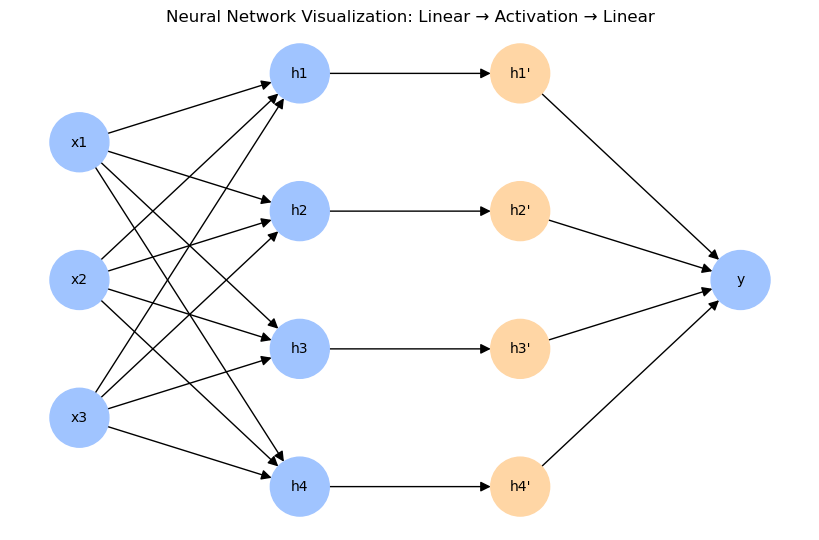

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

# Neural network architecture: x -> h -> h' -> y
layers = {
    "input": ["x1", "x2", "x3"],
    "linear_hidden": ["h1", "h2", "h3", "h4"],
    "activated_hidden": ["h1'", "h2'", "h3'", "h4'"],
    "output": ["y"]
}

G = nx.DiGraph()

# Set positions for visualization
pos = {}
x_positions = [0, 2, 4, 6]
y_positions = {
    "input":  [1, 0, -1],
    "linear_hidden": [1.5, 0.5, -0.5, -1.5],
    "activated_hidden": [1.5, 0.5, -0.5, -1.5],
    "output": [0]
}

# Add nodes
for i, layer in enumerate(layers.keys()):
    for j, node in enumerate(layers[layer]):
        G.add_node(node)
        pos[node] = (x_positions[i], y_positions[layer][j])

# Connect input → linear hidden
for x in layers["input"]:
    for h in layers["linear_hidden"]:
        G.add_edge(x, h)

# Connect linear hidden → activated hidden
for h, hp in zip(layers["linear_hidden"], layers["activated_hidden"]):
    G.add_edge(h, hp)

# Connect activated hidden → output
for hp in layers["activated_hidden"]:
    G.add_edge(hp, layers["output"][0])

# Draw graph
plt.figure(figsize=(8,5))
nx.draw(G, pos,
        with_labels=True,
        node_color=["#a0c4ff" if "'" not in n else "#ffd6a5" for n in G.nodes()],
        node_size=1800,
        arrowsize=15,
        font_size=10)

plt.title("Neural Network Visualization: Linear → Activation → Linear")
plt.axis('off')
plt.show()


자 이 신경망 모델의 이미지는 x1, x2, x3라는 숫자가 들어가서, 네 개의 중간값이 만들어지고, 그 중간값이 활성화함수를 거치고, 그렇게 변형된 중간값을 종합해서 어떤 최종적인 결과를 만드는 형태를 보여주고 있습니다. 

그림에 나오는 동그라미들을 보통 노드, node 라고 부릅니다. 네트워크 과학 응용 분석할 때 익숙해지신 용어일 것입니다. 지금 한 열에 여러 노드가 정렬되어 있는데요, 각각을 묶어서 하나의 층, layer라고 부릅니다. 예를 들어 x1, x2, x3는 하나로 묶여서 입력층 (input layer)라고 불리고, h1-4는 은닉층 (hidden layer)라고 불립니다. y는 출력층이죠. 출력 노드가 하나 밖에 없어서 출력층이라고 불리는게 좀 어색할 수도 있지만, 출력값이 여러개인 경우도 있음을 염두에 두면 그리 어색하지 않습니다. 

보통 활성화함수는 하나의 hidden layer에서 처리되는 내부 연산으로 보는 경우가 경우가 많습니다. 이 이미지에서는 의도적으로 그 과정을 보여드리기 위해 따로 노드를 분류했습니다만, 보통은 하나의 레이어로 표현하죠. 그래서 이 신경망은 세 개의 층이 있다고 보통 표현합니다. 그리고 이걸 보통 2층 신경망이라고 말하곤 합니다. 입력층은 전체 층 수에서 제외하는 경우가 많거든요. 

사실 아주 정확하게 표현하자면 편향에 해당하는 노드도 그려넣어야 하지만, 여기서는 너무 복잡해지는 효과가 발생하니 빼겠습니다. 아마도 야생(?)에서 이런 이미지를 종종 보셨을 것입니다. 워낙에 딥러닝이 대세인 시대라서요 ㅎㅎ

사실 이 이미지는 함수로는 더 깔끔하게 표현이 됩니다. x에서 h로 넘어가는 것을 그냥 만들어진다고 표현했는데, 구체적으로는 어떤 일이 일어나는 것일까요? 그냥 곱하기와 더하기가 일어나는 것입니다. 즉 h1 = w1x1+w2x2+w3x3+b 와 같은 방식으로 만들어집니다. 이런걸 '선형 변환' 이라고 하죠 (linear transformation) 개별 값이 아니라 벡터를 도입해서 표현하면 간단하게 H = WX + b 와 같은 형태로 표현할 수 있습니다. 그러면 저 전체 그림은 아래와 같이 표현할 수 있죠. 

$$
\begin{aligned}
y = W_2 \times (\text{activation}(W_1 \times X + b_1)) + b_2
\end{aligned}
$$

#### 여기서 행렬 연산의 의미에 대해서 간단히 집어줄 것 (보충 필요)

여기서 이 모델의 표현력에 아주 핵심적인 역할을 하는 것이 바로 활성화 함수 파트입니다. 모델의 표현력이란, 그 모델이 어떤 입력에 대해 어떤 출력 패턴을 재현할 수 있는지, 즉 그 모델이 근사 가능한 함수의 종류가 얼마나 다양한지를 의미합니다. 함수가 입력과 출력 사이의 패턴이니까요. 예를 들어 $y = ax+b$는 '직선'이라는 패턴 혹은 함수 밖에 구현하지 못합니다. 반면 $y = ax^2+bx+c$ 라는 모델은 곡선 패턴 혹은 함수도 구현하지요. 그래서 회귀분석할 때 종종 소득 같은 변수를 제곱해서 넣곤 하는 것입니다. 그래야 소득이 응답변수에 미치는 곡선 패턴을 적합할 수 있으니까요. 즉 모델은 자기 형태에 따라 고유한 표현력을 가집니다. 그런데 신경망 모델에서는 이 활성화함수가 없다면, 표현력이 매우 제한되는 일이 생깁니다. 왜 그럴까요? 저 위 수식에서 activation 파트만 사라지게 해보죠. 그러면 아래와 같이 됩니다. 

$$
\begin{aligned}
y = W_2 \times (W_1 \times X + b_1) + b_2
\end{aligned}
$$

그런데, 이건 그냥 계산을 나눠놨을 뿐, 선형 변환을 두 번 한 것에 불과합니다. 선형 변환의 합성은 한 번의 선형 변환으로도 표현할 수 있습니다. 예를 들어 '어떤 숫자에 3을 곱하고 2를 더한 후, 그 결과에 2를 곱하고 5를 더하라' 라고 말하는 것은 2(3x+2)+5 라고 말하는 셈이죠. 그런데 이건, 다 풀어보면 6x+9로 간단히 그냥 표현할 수 있습니다. 즉 애초에 '어떤 숫자에 6을 곱하고 9를 더해라' 라고 말하는 것과 다를게 없는 거죠. 즉 위의 수식은 아래와 같이 정리됩니다. 

$$
\begin{aligned}
y &= W_2 \times (W_1 \times X + b_1) + b_2 \\
y &= W_3 \times X + b_3
\end{aligned}
$$

이렇게 되면, 신경망이 아무리 층이 많고 거대해도, 그 신경망 모델이 표현할 수 있는 패턴 혹은 함수는 선형 함수로 제한됩니다. 기하학적으로는 hyperplane으로 제한되어서, 구부러지는 등의 패턴은 표현할 수 없죠. 활성화 함수는 이를 극복하는 핵심 파트입니다. 즉 중간층의 각 값들을 비선형으로 다르게 변환하여, 선형 변환으로는 표현할 수 없는 다양한 패턴을 표현하게 되는거죠. 사실 이런 활성화함수가 여러 번 중첩되기에 신경망/딥러닝 모델의 표현력이 좋은 것입니다. 표현력이 좋다는 말은, 입력과 출력 사이에 있는 체계적이지만 복잡미묘한 패턴을 잘 학습하여 재현한다는 말인데, 그 덕분에 우리가 신경망/딥러닝 알고리즘으로 학습된 다양한 기계의 놀라운 기능을 누리고 있는 거죠. 예를 들어 여러분이 ChatGPT나 Claude 같은 서비스에 '오늘 내가 발표에서 잘 할 수 있도록 힘을 줘'라고 입력하면 '당신은 이미 잘 준비되어 있고, 자신감을 가지고 발표하면 됩니다. 다만 이런저런 부분은 염두에 두세요' 라고 기계가 응답할 수 있는 것은, 자연어 입력과 출력 사이에 미묘한 패턴을 잘 학습하여 재현하고 있다는 뜻입니다. 그리고 이런 것은 선형 패턴으로는 좀처럼 모사하기 힘들죠. 그 복잡한 패턴을 가능케 한 것이, 원리적으로는 바로 저런 비선형 활성화 함수입니다. 

사실 퍼셉트론에도 활성화 함수가 있었습니다. 계단 함수 (step function)가 그것입니다. 0보다 크면 1, 0보다 작거나 같으면 0으로 만드는 함수를 우리는 계단 함수라고 부릅니다. 이것도 원칙적으로는 비선형 함수이긴 합니다만, 이 함수로는 모델의 표현력을 확장하기가 어렵습니다. 간단히 살펴보면 1) 대부분의 구간에서 미분계수가 의미가 없어서 (미분 불가능한 부분과 0인 부분으로 나뉘거든요^^;;) 학습에 별 도움이 안되고, 2) 0과 1이라는 딱 두 가지 옵션으로 출력을 한정하기 때문에 입력에서 존재하는 미세한 차이 정보가 손실되기 때문입니다. 그래서 비선형 함수이기는 하지만, '선형이 아니다'라는 것만 만족할 뿐, '선형을 넘어선 패턴을 표현하고 잡아낸다'는 만족하지 못하죠. 

그래서 신경망 알고리즘은 다양한 활성화 함수를 도입합니다. 엄청 많지만, 여기서는 딱 네 개만 알아보겠습니다. Sigmoid, Hyperbolic Tangent, ReLU(Rectified Linear Unit) GELU(Gaussian Error Linear Unit)가 우리가 살펴볼 네 개의 비선형 활성화 함수입니다. 일단 아래 코드를 실행시켜서, 각 함수가 어떻게 생겼고, 구간에 따라 미분 계수가 어떻게 변화하는지를 살펴보겠습니다. 

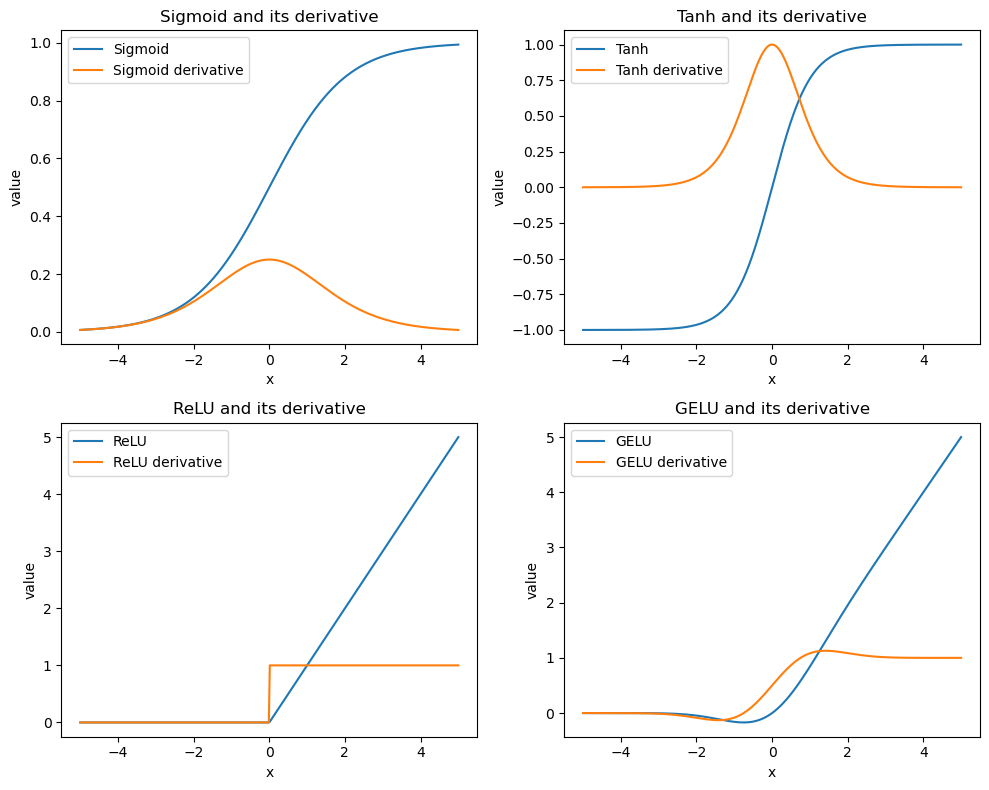

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Activation functions and derivatives
def sigmoid(x):
    return 1/(1+np.exp(-x))

def d_sigmoid(x):
    s = sigmoid(x)
    return s*(1-s)

def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(0, x)

def d_relu(x):
    return (x > 0).astype(float)

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi)*(x + 0.044715*x**3)))

def d_gelu(x):
    t = np.tanh(np.sqrt(2/np.pi)*(x + 0.044715*x**3))
    dt = (1 - t**2) * np.sqrt(2/np.pi) * (1 + 3*0.044715*x**2)
    return 0.5*(1 + t) + 0.5*x*dt

# Generate x-axis
x = np.linspace(-5, 5, 400)

# Prepare figure
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

activations = [
    ("Sigmoid", sigmoid, d_sigmoid),
    ("Tanh", tanh, d_tanh),
    ("ReLU", relu, d_relu),
    ("GELU", gelu, d_gelu),
]

# Plot
for ax, (name, f, df) in zip(axs.flatten(), activations):
    ax.plot(x, f(x), label=f"{name}")
    ax.plot(x, df(x), label=f"{name} derivative")
    ax.legend()
    ax.set_title(f"{name} and its derivative")
    ax.set_xlabel("x")
    ax.set_ylabel("value")

plt.tight_layout()



차례대로 살펴보겠습니다. 

**Sigmoid function**

시그모이드 함수와 도함수(미분 계수를 출력하는 함수)를 수식으로 쓰면 이렇습니다. 

$$
\begin{aligned}
\sigma(x) &= \frac{1}{1+\exp(-x)} \\[15pt]
\sigma'(x) &= \sigma(x)(1-\sigma(x))
\end{aligned}
$$

- 이 함수는 그래프에서 보다시피, 입력이 들어오면 그것을 0과 1사이로 부드럽게 전환시키는 역할을 합니다. 0과 1사이의 값을 가지도록 하기 때문에 출력이 '확률'의 의미를 가져야 할 때 자주 활용됩니다. 로지스틱 회귀분석 등을 배우실 때 링크 함수로 활용되는걸 보셨을텐데, 그 때에도 확률이 필요해서 사용된 것이죠. 
- 도함수 그래프에서 보다시피, 전 영역에서 미분 가능하다는 것도 신경망 알고리즘에서는 장점입니다. 나중에 보겠지만, 결국 미분 계수를 토대로 학습이 이루어지거든요. 
- 다만 몇 가지 단점도 있는데, 지금 시각화된 영역 바깥에서는 (즉 절대값이 4보다 큰 경우) 값이 거의 0 아니면 1로 수렴하고 있다는 것입니다. 이건 계단 함수처럼 명시적으로 0과 1을 출력하는 것은 아니지만, 거기에 거의 가까운 값으로 만들어버리기 때문에 절대값이 큰 입력들 사이의 차이가 거의 무화되는 효과가 있습니다. 
- 그런 영역에서는 미분 계수도 거의 0에 가깝습니다. 그러니 학습에도 문제가 있지요. 
- 이런 문제 때문에 실제 프로젝트에서 hidden layer 위치에서 아주 많이 활용되는 것 같지는 않습니다. 하지만 여전히 값을 0과 1사이로 압축해야 한다거나, 스위치 같은 역할을 하게 한다거나(어떤 신호를 크게 억제하거나 통과시키는 역할을 하는 거죠), 출력이 확률의 함의를 가져야 할 때에는 활용되곤 합니다. 

**Hyperbolic Tangent function**

Tanh 함수와 도함수(미분 계수를 출력하는 함수)를 수식으로 쓰면 이렇습니다. 

$$
\begin{aligned}
\tanh(x) &= \frac{\exp(x) - \exp(-x)}{\exp(x)+\exp(-x)} \\[15pt]
\tanh'(x) &= 1-\tanh(x)^2
\end{aligned}
$$

- 이 함수는 그래프에서 보다시피, 입력이 들어오면 -1과 1사이로 부드럽게 전환시키는 역할을 합니다. 시그모이드가 가졌던 범위를 더 넓혀주는 식이랄까요. 
- 도함수 그래프도 0주위에서만 값이 크고 양족 끝으로 갈수록 0으로 가는 모습이 시그모이드와 유사합니다. 
- 이 역시 시그모이드처럼 대부분의 값이 -1과 1로 간다는 점, 대부분의 구간에서 미분 계수가 0이라는 점 때문에 학습 과정에서 문제를 노출하는 경우가 많고, 그래서 hidden layer로 많이 쓰지는 않습니다. 
- 하지만 역시 꼭 출력이 -1과 1사이로 수렴해야 하고, 가급적이면 -1과 1에 유사한 값이 나와줘야 하는 경우 (예를 들어 출력층이 '방향'을 표하게 하고 싶은 경우라든가) 사용됩니다. 

**ReLU**

Relu 함수와 도함수(미분 계수를 출력하는 함수)를 수식으로 쓰면 이렇습니다. 

$$
\begin{aligned}
\mathrm{ReLU}(x) &= \max(0, x) \\[15pt]
\mathrm{ReLU}'(x) &=
\begin{cases}
0, & x < 0, \\[6pt]
1, & x > 0
\end{cases}
\end{aligned}
$$


- 딥러닝에서 가장 상징적인 활성화 함수입니다. 이것이 도입된 이후 여러 과제의 성능이 엄청 올라갔거든요 (물론 이것 때문만은 아니지만요^^;;)
- 간단합니다. 입력이 0보다 작으면 0, 그보다 크면 그대로 출력합니다. 
- 시그모이드나 하이퍼볼릭 탄젠트처럼 값이 커지면 미분 계수가 0이 되는 일이 없습니다. 그래서 학습에서 유리합니다. 
- 구현이 간단하고, 별 도움이 안되는 신호들을 꺼버려서 모델이 지나치게 복잡해지지 않게 만드는 일종의 정규화 효과를 가져다 줍니다. 
- 다만 음수 영역에서는 미분 계수도 0이고, 별 차이가 없게 출력을 해버리기 때문에 해당 입력과 관련된 뉴런들이 죽어버리는, 즉 아무 역할을 못하는 효과가 발생할 수 있습니다. 
- 0에서는 미분 불가능하다는 이론적 문제도 있는데, 그냥 0에서의 미분 값을 0이나 1로 정해버려서 극복하곤 합니다. 실질적으로는 큰 문제는 아닙니다. 

**GeLU**

Gelu 함수와 도함수(미분 계수를 출력하는 함수)를 수식으로 쓰면 이렇습니다. 

$$
\begin{aligned}
\mathrm{GELU}(x) &= 
0.5\,x\left(1+\tanh\!\left(\sqrt{\frac{2}{\pi}}\left(x+0.044715\,x^3\right)\right)\right) \\[12pt]
\mathrm{GELU}'(x) &= 
0.5\left(1+\tanh\!\left(\sqrt{\frac{2}{\pi}}\left(x+0.044715\,x^3\right)\right)\right) \\[6pt]
&\quad {} + 
0.5x\left(1 - \tanh^2\!\left(\sqrt{\frac{2}{\pi}}\left(x+0.044715\,x^3\right)\right)\right)
\sqrt{\frac{2}{\pi}}\left(1+3\cdot0.044715\,x^2\right)
\end{aligned}
$$



- 사실 함수 형태가 상당히 복잡한데, 아주 이론적으로 보자면 $GELU(x) = x\Phi(x)$ 입니다. $\Phi(x)$는 표준정규분포의 누적분포함수입니다. 위의 수식은 이걸 근사한 것이라 보시면 되고, 실제로는 저것이 많이 활용됩니다. 그냥 그림으로 기억하시는게 나을 겁니다. 
- ReLU보다 부드럽고 연속적이어서 미분 불가한 구간이 없고 그래서 학습 안정성이 있다고 합니다. 깊은 모델에서 잘 작동하고, 미분 계수로 전달되는 정보를 죽이지 않습니다.
- 확률적 게이트의 성격을 가지는데, 값이 크면 대부분 살려서 통과시키고, 작으면 0에 가깝게 억제하기 때문입니다. 표준정규분포의 누적분포함수가 '대부분 통과'냐 '대부분 억제'냐를 결정하도록 0과 1사이의 값을 주는거죠 (값이 크면 1에 가깝게, 작으면 0에 가깝게). 그래서 음수라고 완전히 차단하기보다, 표현을 좀 남겨줘서 미세 조정이 가능합니다. 
- Transformer 계열의 모델에서 매우 많이 활용됩니다. NLP 계열의 모델에서 많이 활용됩니다. 
- 다만 계산 부담이 좀 크고, 이해하기도 쉽지 않고, ReLU랑 딱히 결과에 별 차이가 없는 경우도 있습니다. 


이런 비선형 활성화함수들이 hidden layer에 들어가서 값들을 비선형적으로 변환시켜주니, 신경망 모델의 표현력이 커지는 것입니다. 

**Softmax**

마지막으로, 출력층에 많이 쓰이는 활성화함수인 Softmax 함수를 살펴보겠습니다. 이건 은닉층에서 값을 변환시켜 모델의 표현력을 향상시키려는 목적은 아니지만, 문헌에 따라 활성화함수라고 불리기도 합니다. 수식은 다음과 같습니다. 

$$
\begin{aligned}
softmax(z_i) = \frac{exp(z_i)}{\sum_{j=1}^K exp(z_j)}
\end{aligned}
$$

- 즉 여러 값이 들어가면, 그들 사이의 상대적 크기를 고려해 각 값을 확률로 전환하는 함수입니다. 
- 지수 위에 원래 값이 들어가기 때문에, 여러 값 중에서 가장 큰 값, 즉 maximum value가 다른 값과 가지는 거리를 더 크게 벌려버리는 효과가 생깁니다. 즉 원래 값은 약간 더 컸는데, 확률로 하면 훨씬 더 커지는 것이죠. 그래서 최대값으로 결정을 유도하는데, 그냥 완전히 결정적으로 뽑는대신 부드럽게 유도한다고 해서 softmax라 불리는거 아닌가 싶습니다. argmax 같은 함수와 비교해보면 최대값이 아닌 값들도 확률을 일정 부분 부여받으니까요. 
- 다중 분류 문제에서 많이 활용됩니다. 어떤 범주에 해당할지에 대한 확률 분포로 최종 결과를 전환하기 때문입니다. 
- 다만 계산 부담이 좀 있어서, 변형 판을 사용하는 경우가 많습니다. 

## 4. 모델 파라미터의 학습과 미분

자 좀 길어지니까^^;; 정리해봅시다. 이제까지 우리는 무엇을 살펴봤나요? 먼저 신경망 알고리즘은 데이터에서 입력과 출력 사이의 패턴을 찾아내서 활용하는 일을 합니다. 데이터에서 일종의 학습을 하는 것이기에 머신 러닝 알고리즘의 일종으로 여겨집니다. 이 아이디어의 시작은 퍼셉트론이었습니다. 뉴런과 유사한 형태로 모델을 구성하고 학습을 할 수 있음을 보여줬지요. 하지만 비선형 분류기가 될 수 없다는 한계를 지적받아 그 이후 관심을 받지 못했습니다. 하지만 퍼셉트론을 다층으로 구성하면 비선형 분류기가 될 수 있었죠. 여기에 다양한 비선형 활성화 함수가 더해지면 모델의 표현력이 극대화됩니다. 신경망 알고리즘은 다층 퍼셉트론에 다양한 비선형 활성화함수를 결합하고, 층이 깊어졌을 때 실제 정보 전달과 학습 진행이 되도록 여러 도구를 결합한 형태입니다. 그리고 바로 전 쳅터에서 어떤 종류의 비선형 활성화 함수가 있는지 대표적인 것 중심으로 살펴보았습니다. 

자 그럼 다음으로 모델의 파라미터를 학습하는 방법에 대해 알아봅시다. 앞에서는 신경망 모델의 구조를 살펴봤고, 그것이 표현력이 극대화될 수 있는 이유를 살펴봤으니, 이 다양한 가능성을 가지고 데이터에 있는 패턴을 흡수하는 방법을 알아봐야 하겠지요. 그게 학습 알고리즘입니다. 사실 신경망 모델에서 학습 알고리즘은 필수적입니다. 파라미터가 너무 많은 경우가 많습니다. 보통 신경망이 표현력을 늘리기 위해 은닉층을 입력층보다 더 크게 확장하는 일이 많습니다. 즉 입력이 30이라는 길이의 벡터로 들어오는데, 그걸 은닉층에서 60이라는 길이의 벡터로 늘리는 것이지요. 그림으로 표현하자면, 지금 위에 있는 신경망 그림에서 입력층에서 동그라미가 3개에서 30개로 늘어나고, 은닉층은 4개에서 60개로 늘어난다고 보면 됩니다. 그러면 이건 기본적으로 길이 30인 벡터에 (30,60)인 행렬을 곱하는 꼴이 됩니다. 그러면 그때 필요한 숫자만 1800개죠. 이게 여러층이 있다면 어떨까요? 기하급수적으로 파라미터 숫자가 늘어납니다. 이걸 앞서 퍼셉트론에서 임의적으로 숫자 지정하던 것처럼 인간이 지정할 수는 없습니다. 데이터로부터 학습하는 과정이 거의 필수적입니다. 

그럼 이 수많은 파라미터를 어떻게 데이터로부터 단서를 찾아내 현명한 방식으로 설정할 수 있을까요? 기본적인 발상은 '일단 맨 처음에는 파라미터를 무작위로 설정해 둔 다음 데이터를 활용해 확인할 수 있는 모델의 성능이 좋은 방향으로 변경해 나간다'입니다. 데이터는 기본적으로 입력값, 통계적으로 말하자면 '설명 변수'와 출력값, 역시 통계적으로 말하자면 '응답 변수'가 있는 형태를 가정하겠습니다. 그러면 우리 신경망 모델의 과제는 입력, 즉 설명 변수를 받아서, 출력, 즉 응답 변수를 잘 맞춰야 합니다. 입력층에 설명변수들에 해당하는 여러 수치를 입력받아서 최종적으로 출력을 만들 텐데, 그것이 데이터에서 실제 출력값과 유사해야 한다는 말입니다. 

그런데 '모델의 성능이 좋은 방향으로 파라미터를 변경'하려면, 일단 필요한 것이 '모델의 성능'을 평가할 수 있어야 합니다. 보통 이걸 '손실'(loss)을 계산함으로써 달성합니다. 즉 모델이 실패하는 정도를 계량해서 성능으로 이해하는 거죠. 물론 거꾸로 성공하는 정도를 계량할 수도 있습니다만, 일반적으로 손실을 계량하고 그걸 줄이는 방향으로 가는 세팅이 많더라고요. 그러면 이 손실은 어떻게 계산될까요? 요구되는 출력이 어떤 종류의 값인지에 따라 다릅니다. 

1. 요구되는 출력값이 연속적인 수치일 때
- 연속적인 수치를 잘 맞춰야 할 때가 있습니다. 앞서 말한 것처럼 미래의 주가를 맞춰야 하는 상황이 대표적이죠. '회귀문제'라고 표현할 수도 있을 것입니다. 이 경우는 간단합니다. 예측값에서 실제값을 빼면 되죠. 다만 이 경우 예측값이 실제값보다 커서 틀리는 상황과 작아서 틀리는 상황을 동등하게 여겨야 하니, 보통 예측값에서 실제값을 뺀 값을 제고밥니다. 그리고 이렇게 제곱을 하면, 크게 틀리면 크게 틀릴 수록 패널티를 많이 받게 되는 특성도 생깁니다. 1만큼 틀렸을 때는 제곱해도 1이지만, 3만큼 틀리면 제곱하면 9가 되니까요. 이런 일종의 오류 정도를 여러 데이터에 걸쳐 합치고 평균내고 제곱한 효과를 사라지게 하기 위해 제곱근을 취하면, 우리가 흔히 말하는 root mean squared error, 즉 RMSE가 됩니다. 

2. 요구되는 출력값이 한정된 범주 중 하나일 때
- 여러 범주 중 출력이 무엇에 해당되는지 맞춰여 할 때가 있습니다. 예를 들어 사진을 보고 이것이 개인지 고양이인지 다람쥐인지 셋 중에 하나로 맞춰야 하는 상황을 생각해봅시다. 이건 수치를 맞추는 상황이 아니니 RMSE 같은 수치형 손실값을 쓸 수 없습니다. 가장 먼저 생각해볼 수 있는 것은 '맞느냐, 틀렸느냐'를 간단히 0, 1로 계산하는 것입니다. 즉 맞으면 손실 0, 틀리면 1로 계산하는거죠. 이런 방식은 구현이 간단하다는 장점은 있지만, '모델이 아쉽게 틀리는 상황'과 '모델이 확실히 틀리는 상황'을 구분하지 않아 모델이 좋은 방향으로 변해갈 기회를 제공하지 못한다는 단점이 있습니다. 신경망 모델은 이런 상황에서 범주별 확률을 계산하여 판단하는 경우가 많습니다. 예를 들어 어떤 개 사진을 보고 개/고양이/다람쥐 확률이 각각 (0.3, 0.4, 0.3) 이라고 판단하여 고양이를 선택하는 상황과, (0.1, 0.8, 0.1)로 판단하여 고양이로 판단하는 상황을 생각해봅시다. 첫번째는 아슬아슬하게 틀리고 있고 두 번째는 아주 확실히 틀리고 있습니다. 그런데 그냥 맞느냐 틀렸느냐만 보면 두 상황이 동일하죠. 하지만 모델의 변화라는 관점에서 보면, 두 번째 상태에서 첫번째 상태로 이동하게 유도하는 편이 좋습니다. 즉 전자의 손실이 후자의 손실보다 적다고 계산할 수 있어야 합니다. 그래야 모델이 징검다리를 거쳐서 최종적으로 좋은 상태로 이동할 수 있습니다. 
- 그래서 흔히 도입되는 손실 계산 방식이 교차 엔트로피 손실 (Cross-Entropy loss) 입니다. 신경망에서 분류 문제를 풀 때 이건 보통 $E = -\sum_k t_k\log{y_k}$ 같은 방식으로 구현됩니다. 여기서 k는 범주를 가리킵니다. t는 정답 분포를 가리킵니다. 정답은 사실 정해진 값이니 확률 분포가 없는데, 분포꼴로 만들어줍니다. 예를 들어 고양이가 정답이면 (0,1,0)이 되는 셈이죠. 일종의 one-hot vector로 만드는 것입니다. y는 모델의 출력값입니다. 예를 들어 앞서처럼 (0.3, 0.4, 0.3)이라고 확률을 부여했다고 합시다. 지금 cross entropy 수식은 모델의 출력 확률에 로그를 붙이고, 각 범주별로 정답 분포에 해당하는 값과 곱해서 더한 후 마이너스를 붙이라는 말입니다. 즉 $- (0 \times \log{0.3} + 1 \times \log{0.4} + 0 \times \log{0.3})$ 이 되는거죠. 그러면 이 수식은 사실상 '모델이 정답에 해당하는 범주에 어떤 확률을 부여했는지 알아보는' 수치가 됩니다. -log 가 붙어 있으니, 정답에 해당하는 범주에 높은 확률을 부여하면 수치가 작아지고, 낮은 확률을 부여하면 수치가 마구 커지겠죠. 이렇게 하면 앞서 말한 것처럼 '애매하게 틀리는 상황'과 '확실하게 틀리는 상황'도 구분됩니다. 위의 두 가지 예에서 모델은 둘 다 고양이를 맞추지 못했다는 점에서 틀렸지만, 개/고양이/다람쥐 확률을 (0.3, 0.4, 0.3)라고 예측했을 때에는 손실이 $-\log{0.4}$ 이고, (0.1,0.8,0.1)로 예측했을 때에는 $-\log{0.8}$ 이니까요. 
- 여담이지만 일반적으로 보자면 Cross-Entropy는 두 분포 사이의 차이를 계산하는 수치입니다. 지금은 정답을 one-hot vector로 표현하여 분포꼴로 바꿔서 적용한 거죠. 당연히 one-hot vector가 아닌 상황에서도 적용할 수 있을 것입니다. 

자 그럼 우리는 이제 모델의 성능을 꽤나 섬세하게 평가할 수 있는 손실값, loss를 계산할 수 있게 되었습니다. 연속적인 값을 맞춰야 할 때에는 RMSE 같은 수치를 활용하면 될 것이고, 범주형 문제일 경우에도 모델이 확률을 출력하게 한 다음 cross entropy 등을 활용하면 되죠. 이것 이외에도 다양한 가능성이 있습니다. 그러면 다음은 loss를 줄이는 방향으로 모델의 형태를 조정해 나가야 합니다. 어떻게 이것이 가능할까요? 여기서 두 가지가 중요합니다. 

첫 번째, 손실은 데이터가 고정된 상황이라면 모델 파라미터에 따라 변화하는 값이 됩니다. 모델의 형태란 곧 그 모델을 구성하는 파라미터값이 무엇이냐입니다. 예를 들어 y = ax+b라는 모델이 있고, 이 모델이 x라는 입력에 따라 y라는 출력을 준다고 하죠. 이때 a와 b에 어떤 숫자가 있냐가 모델의 형태를 결정합니다. 이걸 파라미터라고 합니다. 그리고 손실은 바로 이런 파라미터에 따라 변동하는 값이 됩니다. 모델이 입력을 어떻게 처리하느냐에 따라 출력을 얼마나 정교하게 맞추냐가 정해지기 때문입니다. 신경망에 적용해보자면, 위에 그려본 신경망 모델에서 입력층에서 은닉층으로 가는 화살표에 실린 가중치들이 어떻게 설정되느냐 (즉 가중치 행렬이 어떻게 설정되느냐), 편향이 어떻게 설정되어 있느냐 등이 모델이 입력값을 받아 어떤 출력값을 산출할지 결정합니다. 손실은 당연히 이런 모델의 행동 방식에 영향을 받습니다. 그런 의미를 담아 우리는 손실이 모델의 파라미터에 따라 변동하는 값이라고 봅니다. 손실은 모델 파라미터가 특정한 함수를 거쳐 결정되는 값이라는 말입니다. 

두 번째, 그렇기에 우리는 손실이 모델 파라미터들에 대해 가지는 ‘미분계수’를 구할 수 있습니다. 잠깐 고등학교 시절로 돌아가봅시다. 미분계수란 뭔가요? 그건 어떤 함수의 결과가 그 함수의 들어가는 변수가 아주 미세하게 증가할 때 어떻게 변화하는지 표현하는 값입니다. 예를 들어 우리가 y=x^2이라는 함수를 x에 대해 미분하면 2x라고 하죠. 그리고 x가 2일 때 y가 x에 대해 가지는 미분 계수가 4라고 했습니다. 이는, x의 값이 2에서 미세하게 증가하면 그때 y는 4라는 기울기로 증가한다는 말이 됩니다. 방향과 그런 방향이라는 경향의 강도를 표현하는 것입니다. 

이걸 파라미터에 따라 변동하는 손실에 그대로 적용시켜볼 수 있습니다. 즉 손실이 각 파라미터에 대해 가지는 미분계수는, 각 파라미터가 미세하게 증가할 때 손실이 어떻게 움직이는지 알려주는 값이 됩니다. 위의 예를 그대로 적용하자면, x가 어떤 파라미터라고 하고 (우리가 적절하게 세팅하고 싶은) y가 손실이라고 보는 셈입니다. 이 때 y가 특정한 x값에 대해 가지는 미분계수를 알면, x가 그 값에서 더 늘어날 때 y가 어떻게 움직이는지 알 수 있습니다. 즉 파라미터값을 지금보다 더 늘렸을 때 손실이 늘어날지 줄어들지 알 수 있는 것이지요. 

신경망 모델을 구성하는 여러 파라미터들을 조정하는 방식의 요체는 바로 이것입니다. 일단 초기값을 부여합니다. 그런 다음, 손실이 파라미터의 값들에 대해 가지는 미분 계수를 구합니다. 그런 다음, 각 파라미터값을 그 미분계수가 가리키는 방향의 반대로 조금씩 이동시킵니다. 당연합니다. 미분계수가 양수라면, 그건 해당 파라미터의 값이 지금보다 미세하게 늘어날 때 손실도 증가한다는 뜻입니다. 그러면 해당 파라미터는 값을 줄여야겠지요. 반대로 미분계수가 음수라면, 그건 해당 파라미터의 값이 지금보다 미세하게 늘어나면 손실이 줄어든다는 뜻입니다. 그러면 해당 파라미터는 값을 늘려야겠지요. 더불어 미분계수의 크기, 즉 절대값은 이런 방향으로 가는 경향의 강도를 (기울기가 그거죠) 의미할테니, 이것을 늘리거나 줄이는 정도에 반영하면 좋을 것입니다. 이 과정을 모든 파라미터에 대해 여러 번 반복하는 것입니다. 그러면 모델이 점점 최적화된다고 보는 거죠. 

이것이 경사하강법, Gradient Descent algorithm의 핵심입니다. 일단 gradient는 본질적으로 편미분계수를 묶어놓은 벡터입니다. 일단 편미분계수가 뭔가요? 우리가 처음 미분을 배울 때는 단변수 함수를 대상으로 했습니다. 앞서 말한 y=x^2이 그런거였죠. 이 경우 y는 오로지 x에 의해 결정됩니다. 그러면 다변수 상황은 어떨까요. Y = x^2+z 같은 상황이 있을 수 있습니다. 이 경우 y는 x에 의해서도 변동하고, z에 의해서도 변동하니까요. 이 경우 미분계수는 두 개가 됩니다. X가 미세하게 변동할 때 y가 변동하는 방향과 z가 미세하게 증가할 때 y가 변동하는 방향이 따로 있으니까요. 이 각각의 미분 계수를 ‘편미분계수’라고 합니다. 각각의 변수에 대한 미분계수를 계산할 때 나머지 변수는 고정되었다고 가정하고 미분계수를 계산하는거죠. Gradient는 한 함수에 존재하는 모든 변수의 미분계수를 벡터로 묶은 것입니다. 자연스러운 일입니다. 다변수 함수의 형태가 결정되려면 입력 자체가 벡터로 들어가야 합니다. X도 들어가고 z도 들어가야 y가 결정되니까, (x,z) 같은 벡터가 위에 있는 다변수 함수의 입력값이 되죠. 그래서 이런 입력값에 대해 가지는 함수의 미분계수를 표현하기 위해 각 변수의 편미분계수를 벡터로 묶어서 표현합니다. 그게 gradient입니다. 

Gradient descents는 그래서 미분계수의 반대 방향으로 변수를 조정한다는 말을 벡터 관점에서 하고 있는 것입니다. 구체적으로 gradient descent는 아래와 같은 수식으로 표현됩니다. 

$$
\begin{aligned}
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} L(\theta_t)
\end{aligned}
$$

여기서 에타$\eta$라고 표기된 것은 학습률입니다. $\nabla_{\theta} L(\theta_t)$이 부분이 손실값이 파라미터($\theta$)의 현재값 ($\theta_t$)에 대해 가지는 그레디언트를 표현합니다. 그레디언트는 앞서 말했듯 미분계수이고, 그것은 파라미터가 미세하게 증가할 때 손실이 어떤 방향으로 어느 정도의 강도로 변경하는지 알려줍니다. 기울기가 바로 이런 방향과 강도를 포괄한 개념입니다. 이 방향과 강도를 고려하여 얼마나 움직일지는 분석자가 정해주는 학습률과 미분계수를 곱해져서 만들어집니다. 즉 학습률은 분석자가 정해주는 기본 스텝의 거리라고 할 수 있습니다. 기본적으로 점진적인 업데이트를 가정하는데, 하나의 그레디언트에서 얼마나 모델을 변동시킬지 분석자가 통제하려는 것이죠. 보통 작은 상수를 할당하는 경우 많습니다. (예를 들어 0.0001) 그렇지 않고 학습률, 즉 보폭이 크면, 모델의 형태 변화를 섬세하게 가져가지 못해 손실이 최소가 되는 지점으로 이동하지 못하고 좋지 못한 성능을 지닌 형태 사이에서 진동하는 일이 생기거든요. 요컨대 위에 수식에 나와 있는 방식을 써서 각 파라미터를 여러 데이터를 거쳐 갱신해나가면 신경망 모델의 성능이 향상되는 것으로 알려져 있습니다. 

이제야 말씀드리지만, 앞서 손실을 모델의 상태 변동에 따라 민감하게 변동하도록 노력한 것도, 사실 그것의 미분 가능성을 확보하기 위함이기도 했습니다. 그래야 이런 미분 기반 방법을 적용할 수 있거든요. 어떤가요? 우리가 모두 알고 있는 미분의 성질을 영리하게 활용한 접근이죠. 여담이지만, 이런 분야를 공부하기 위해 수학을 잘해야 한다는 말을 많이 하곤 합니다. 어느 정도는 동의합니다. 컴퓨터와 소통하는 근본적인 방식은 수학과 코드이니까요. 다만 그 수학 실력이 수능에서 1등급을 받고 킬러 문항을 기가막히게 푸는 그런 능력만을 의미한다고 생각하지는 않습니다. 그것도 중요하지만, 지금처럼 상황을 수학적으로 번역하고 (모델의 상태에 따라 오류가 다를 수 있다 -> 손실은 파라미터 값을 변수로 가지는 함수의 결과이다) 적합한 수학적 도구를 활용할 수 있는 능력 (미분계수를 활용해서 최적점을 통해 점진적으로 나아가자) 을 의미하기도 합니다. 즉 상황의 수학적 번역 능력이랄까요. 그건 문과 이과를 떠나서 배양해야 하는 능력입니다. 


## 5. Gradient descent의 다양한 발전: Grandient-based optimizers

신경망 혹은 딥러닝 모델의 학습은 기본적으로 이처럼 손실이 파라미터들에 대해 가지는 미분계수를 활용하는 방식으로 이루어집니다. 다만 이런 경사하강법을 그대로 적용하는 경우는 드뭅니다. 큰 틀은 유지하되, 다양한 방식으로 발전했습니다. 그것들 모두를 살펴볼 수는 없지만, 지금부터 중요한 것들 위주로 몇 가지만 살펴보겠습니다. 

1. Momentum

모멘텀부터 살펴보겠습니다. 물리학 용어인데, 질량과 속도의 곱을 가리키고, 직관적으로 설명하자면 물체가 한 방향으로 계속 변동하려는 경향을 가리킬 때 쓰입니다. 파라미터를 업데이트할 때 이런 일종의 관성적 변동을 주자는 것입니다. 파라미터를 업데이트할 때 가장 비효율적인 일이 값이 진동하는 것입니다. 열심히 분석해서 업데이트했는데, 예전에 했던 업데이트를 무화시켜버리니까요. 어딘가 좋은 곳으로 가야 하는데 왔다갔다 하는 셈이죠. 그런데 사실 데이터마다 모델 성능이 다를 수 밖에 없으니 데이터가 달라졌을 때 미분계수가 보이는 방향이 달라지는 건 흔한 일입니다. 모멘텀은 그걸 좀 줄이고 큰 방향을 유지해가려는 기술입니다. 이것은 파라미터 업데이트 방식을 아래와 같이 바꿉니다. 

$$
\begin{aligned}
V_t &= \beta \cdot V_{t-1} + \eta \nabla_{\theta} L(\theta_t) \\
\theta_{t+1} &= \theta_t - V_t
\end{aligned}
$$



보시면 목적은 명확합니다. t 시점에 손실이 파라미터들에 대해 가지는 그레디언트를 그대로 활용하는 것이 아니라, 그 전에 움직였던 방향을 유지하고 싶은 것입니다. V가 그런 역할을 하고 있습니다. t 시점의 V는 기존에 움직였던 방향($V_{t-1}$)을 일정부분 유지하고, 거기에 현재 그레디언트에 학습률을 곱한 값으로 만들어집니다. 그걸 활용해서 파라미터를 업데이트 하면 기존에 파라미터가 갱신된 방향이 유지되는 효과가 생기죠. 그래서 여기서 $\beta$를 관성계수라고 부릅니다. 그 값에 따라 기존의 변화 방향을 얼마나 유지할지 결정되거든요. 주로 0과 1사이의 값을 가지게 만들고, 0.9 같은 값을 가지는 경우가 흔합니다. 

2. Adagrad

Adagrad는 Adaptive Gradient의 준말인데요, 핵심 아이디어는 학습이 진행됨에 따라 파라미터마다 학습률을 다르게 적용하는 것입니다. 즉 학습 중에 파라미터 중 이제까지 미분계수가 크게 관찰된 경우가 많아 자연스럽게 많이 변동된 파라미터는 덜 변동시키고, 이제까지 그레디언트가 크지 않게 관찰되어 자연히 많이 변동되지 않은 파라미터는 많이 변동시키는 방법이라고 할 수 있습니다. 왜 이런 변형이 필요할까요? 이건 데이터마다 모델 변형을 자극하는 유도하는 포인트가 다르기 때문에, 자칫 특정 부분만 많이 학습되는 일이 일어날 수 있기 때문입니다. 앞서 손실이 파라미터의 함수라고 했습니다. 파라미터가 변형됨에 따라 손실값이 달라진다는 말이죠. 그런데 잊지 말아야 할 것이 이 과정에서 데이터가 개입한다는 점입니다. 데이터는 파라미터 변동에 따른 손실값 변동의 구조적 요인으로 작동합니다. 손실이 파라미터에 대해 가지는 미분계수는 특정한 데이터가 파라미터의 환경으로 설정된 상태에서 계산됩니다. 모델의 파라미터는 이 특정 데이터를 잘 설명하는 방향으로 변형되려고 하죠. 그렇기에 원리적으로 데이터에 따라 파라미터에게 요구되는 변형 방향이 다르고, 데이터에 따라 수많은 파라미터 중 어떤 파라미터에 변형 압력이 강하게 가해지는지가 달라집니다. 예를 들어 1차 함수꼴 모델을 점진적으로 변형하는데, 어떤 데이터는 기울기 변동을 더 강하게 요구한다면 (이 경우 기울기를 좌우하는 파라미터의 미분 계수가 크겠죠), 다른 데이터는 절편 변동을 더 강하게 요구할 수 있는거죠. (이 경우에는 절편을 표현하는 파라미터의 미분계수가 클 것입니다)

그런데 이런 상태에서 데이터가 여러개 주어지는데, 그 데이터들이 모델의 특정 부분의 파라미터 변형만을 유도한다면, 학습되지 않는 파라미터 파트가 남게 됩니다. 이들은 초기에 무작위로 주어진 상태에서 많이 변형되지 않으니 모델 성능에 기여하는 면이 많을 수가 없죠. 그래서 Adagrad는 각 파라미터가 이제까지 보여준 미분계수의 크기 정도를 계량합니다. 그리고 그것이 커서 변동 정도가 많았던 파라미터는 적게 변경하고, 거꾸로 그 수치가 작아 변동 정도가 적었던 파라미터는 많이 변경하도록 합니다. 이걸 각 파라미터마다 학습률을 달리 적용함으로써 달성하는거죠. 즉 정해진 데이터에서 미분계수를 통해 각 파라미터의 변동 방향에 대한 정보를 뽑아내고, 그 중 이제까지 많이 변동하지 않았던 파라미터에 대한 정보를 좀 더 강조해서 활용한다는 말입니다. 

수식은 아래와 같습니다. 

$$
\begin{aligned}
G_t &= G_{t-1} + g_t^2 \\
g_t &= \nabla_{\theta} L(\theta_t) \\
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \cdot g_t
\end{aligned}
$$


즉 현재 손실이 파라미터들에 대해 가지는 미분계수를 계산하고, 그것의 제곱을 누적하여 G라는 수치를 만듭니다. 이건, 이제까지 미분계수의 제곱이 누적적으로 얼마나 컸는지를 표현하는데, 이제까지 어느 방향이건 얼마나 많이 변동했는지를 표현합니다. 그런데 그걸, 현재의 미분계수를 업데이트할 때 학습률에 패널티를 주는 방식으로 적용합니다. 마지막 수식 보시면 아시겠지만, $G_t$가 클 수록 학습률이 작아지는 구조입니다. 이렇게 함으로써, 이제까지 많이 변동되었던 파라미터는 그 미분계수에 따른 업데이트를 조금만 시키고, 거꾸로 많이 변동되지 않았던 파라미터는 많이 변동시키는거죠. 이렇게 함으로써, 데이터에 존재하는 일종의 모델 유도 편향을 극복하고 더 좋은 일반적인 모델을 만들 수 있다고 보는 것입니다. 

한 가지 노파심에 덧붙이면, 벡터에 익숙하지 않은 분들은 $G_t$가 하나가 있는데 왜 어떤 파라미터에서는 크고 어떤 파라미터에서는 작다고 하는지 어리둥절할 수도 있을 듯합니다. 제가 그랬거든요. 그런데 저기 나오는 것들이 다 벡터라고 보시면 됩니다. 즉 $G_t$에서 첫번째 원소는 큰데 두 번째 원소는 작고, 이럴 수 있는거죠. 각 위치의 원소가 각 파라미터에 해당하는 것이라고 보면 됩니다. 

아, 그리고 분모에 있는 입실론은, 분모가 0이 되지 않도록 부여하는 아주아주 작은 숫자입니다. 계산 안정성을 위해 컴퓨터에서 흔히 쓰는 방법입니다^^

3. RMSprop

RMSprop 은 Root Mean Square Propagation의 준말입니다. 이건 Adagrad의 아이디어는 계승하되, 그것이 가진 문제는 보완하는 방법입니다. Adagrad가 노출했던 핵심 문제는 너무 빨리 학습율이 0으로 수렴하는 것이었습니다. 위에서 보았듯이, Adagrad에서는 각 파라미터가 이제껏 보여왔던 미분계수의 제곱 누적합이 학습율에 패널티를 주도록 설계되어 있었습니다. 그러면 필연적으로 학습이 진행되면 전반적으로 모든 파라미터의 학습율이 매우 낮아질 수 밖에 없습니다. 그러면 계산 효율성이 매우매우 떨어지겠죠. 어느 순간 제대로 된 학습을 할 수 없게 될 것입니다. 

RMSprop은 지수이동평균이라는 방법으로 해결하려 합니다. 이건 수식을 먼저 보는게 좋겠습니다. 취지는 adagrad와 동일하고, 한계를 보완하려는 기법이니까요. 

$$
\begin{aligned}
E[g^2]_t &= \rho \cdot E[g^2]_{t-1} + (1-\rho)\cdot g_t^2 \\[15pt]
g_t &= \nabla_{\theta} L(\theta_t) \\[15pt]
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{E[g^2]_t} + \epsilon} \cdot g_t
\end{aligned}
$$

adagrad를 계산했던 구조와 유사합니다. $g_t$, 즉 특정 시점의 파라미터 그레디언트를 계산한 후, 모종의 계산을 거쳐 어떤 값을 만들고, 그것으로 학습률을 파라미터 마다 다르게 조정하는 방식입니다. 그런데 그레디언트로 뭔가 수치를 만드는 방식이, adagrad에서는 그냥 제곱값을 누적하는 것이었다면, 여기서는 좀 희한한 수식이 나옵니다. 첫번째 수식을 봅시다. 여기서 $\rho$는 decay rate이라고 불리는데, 0과 1사이의 값을 가집니다. 딱 봐도, momentum에서 나왔던 관성계수랑 유사하게 앞서서 만들어진 값과 지금 만들어진 값을 조합하는 기능을 하죠. 보통 0.9 정도의 값이 많이 설정됩니다. $E[g^2]_0$을 0으로 설정한다면, $E[g^2]_1 = (1-\rho) \cdot g_1^2$ 이 됩니다. 즉 첫번째 지수 평균은 그냥 그레디언트 제곱에다가 1-decay rate을 곱한 값이 됩니다. 그 다음부터는 이 값에 decay rate이 곱해져서 새로운 값에 더해지겠지요. 

이렇게 하면, $E[g^2]_t$가 무작정 커지는 일이 발생하지 않습니다. decay rate이 그것을 억제합니다. 개별 시점의 그레디언트가 계속해서 그대로 더해지는 것이 아니라, 처음 수식에 들어올 때에는 (1-decay rate)이 곱해져서 더해지고, 그 다음부터는 계속 decay rate이 곱해져서 남습니다. 알다시피 0에서 1사이의 소수가 지속적으로 곱해지면, 값이 빠르게 작아집니다. 그러니 기존 그레디언트 값이 누적되긴 하지만 영향력을 계속 잃으면서 누적되는거죠. 오래전의 그레디언트 값일 수록 decay rate가 더 많이 곱해질테니 전체 수치에 미치는 영향을 더 빠르게 상실할 것입니다. 

이런 방식으로 반복되는 값에 근거하여 수치를 만들어내는 것을 '지수이동평균'(exponential moving average, EMA)이라고 부릅니다. 오래된 데이터는 잊어버리고, 최근 데이터는 많이 기억하는 방식의 특이한 평균이라고 생각하면 됩니다. 과거 데이터가 '지수적으로' 빠르게 작아지기에 '지수이동평균'이라고 부르죠. 그걸 그레디언트에 적용한 것이 RMSprop이라고 보면 됩니다. 즉 adagrad는 그레디언트 제곱값의 누적으로 인해 학습률이 급격히 줄어드는 문제가 있었는데, RMSprop은 지수이동평균으로 먼 과거의 그레디언트 값의 영향력을 줄이고 최근 값들 중심으로 기존의 파라미터 변동량을 추정함으로써 이를 극복한 것입니다. 

4. Adam

Adam은 RMSprop/adagrad와 Momentum의 아이디어를 결합하는 최적화 알고리즘입니다. 즉 과거의 변화 방향도 고려하고, 과거의 변화 크기도 고려하여 최적화를 시도하겠다는 거죠. 여기에 지수이동평균이 가진 문제도 추가적으로 해결합니다. 근본적으로 이미 설명한 두 아이디어를 결합하는 것이니 일단 수식을 봅시다. 보시면 아마 이해가 되실겁니다. 추가 사항은 지수이동평균의 편향을 보정하는 절차입니다.  


$$
\begin{aligned}
g_t &= \nabla_{\theta} L(\theta_t) \\[15pt]
m_t &= \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot g_t\\[15pt]
v_t &= \beta_2 \cdot v_{t-1} + (1-\beta_2) \cdot g_t^2\\[15pt]
\hat{m_t} &= \frac{m_t}{1-\beta_1^t}\\[15pt]
\hat{v_t} &= \frac{v_t}{1-\beta_2^t}\\[15pt]
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{\hat{v_t}} + \epsilon} \cdot \hat{m_t}
\end{aligned}
$$

즉 일단 해당 시점에서 그레디언트를 구한 다음에, Momentum에서 하던 것처럼 관성을 고려한 변화 방향을 구합니다. 그게 $m_t$입니다. 그리고 RMSprop에서 하던 것처럼 파라미터 별로 학습률을 조정하기 위해 이제까지의 그레디언트 지수평균값을 구합니다. 그게 $v_t$입니다. $\beta_1$은 모멘텀에서 나왔던 관성계수고, $\beta_2$는 RMSprop에서 나왔던 decay rate이지요. 

앞서 말한 것처럼 이 두 가지 수치의 편향을 보정하는 절차가 $\hat{m_t}$와 $\hat{v_t}$를 만드는 과정입니다. 여기에 무슨 편향이 있냐면, 지수이동평균 자체가 가지는 편향을 의미합니다. 이제야 보시면 아시겠지만, 사실 두 수치 모두 지수이동평균을 적용한 것입니다. 즉 momentum은 그레디언트 자체에 지수이동평균을 적용하여 과거 그레디언트까지 포괄하여 그레디언트 값의 평균적 경향을 산출한 것이고 (그래서 그냥 지금 당장의 값 뿐만 아니라 과거의 값도 영향을 미치도록 했지요), rmsprop은 그레디언트의 제곱에 지수이동평균을 적용하여 이제까지의 그레디언트 제곱의 평균적인 경향을 구해서 학습률을 조정하려 한 것입니다. 그런데 지수이동평균은 초기값은 과거 정보가 쌓여 있지 않아서 지나치게 수치가 작은 문제가 있습니다. 예를 들어 $m_t$를 봅시다. 의도는 과거 그레디언트의 방향을 고려한 변동방향을 만들려는 것인데, $m_1$은 얼마가 되나요? 기존 값이 없어서, $(1-\beta_1) \cdot g_1$이 됩니다. 그리고 보통 관성계수, $\beta_1$은 0.9 같은 수치가 쓰인다고 말씀드렸죠. 그러면 이 말은, $m_1$ 첫번째 미분계수에다가 0.1을 곱한 값이 된다는 말입니다. 이처럼 지수이동평균을 계산하면, 초기의 값들은 지나치게 작아지는 효과가 생깁니다. 지금 $\hat{m_t}$와 $\hat{v_t}$를 산출하는 과정은 그걸 보정하는 과정입니다. 

어떻게 보정하나요? 기본적으로 계산된 $m_t$와 $v_t$를 $1-\beta_1^t$와 $1-\beta_2^t$로 나눠주고 있습니다. 이렇게 되면, 처음에는 1보다 작은 값으로 나눠지고 뒤로 갈수록 1에 가까운 값으로 나눠주는 효과가 생깁니다. 두 베타값은 0과 1사이의 값이니까요. 그러면 초기에는 값을 키워주다가, 나중에 갈수록 그냥 값을 거의 변형없이 반환하는 효과가 생기지요. 이를 통해 지수이동평균이 가지는 편향을 적절히 보정하는 효과가 생깁니다. 

그리고 이렇게 편향이 보정된 두 값을 고려해서 파라미터를 업데이트하는거죠. 이 Adam은 많은 과제에서 성능이 좋은 것으로 널리 알려져 있어서 기본적인 모델에서 많이 써보는 최적화 알고리즘 중 하나입니다. 


5. AdamW

사실 그레디언트 기반 최적화 알고리즘은 하다보면 끝이 없습니다만, 그래도 우리가 NLP가 포인트이니, NLP에서 많이 활용되는 최적화 알고리즘인 AdamW만 추가적으로 알아보고 종료하겠습니다. BERT, GPT 등에서 활용되어 사실상 표준 알고리즘처럼 쓰이는 알고리즘입니다. 이건 Adam에 L2 regularization의 취지를 더한 것입니다. 

L2 regularization이란 무엇인가요? 이건 모델의 파라미터 값의 절대적 크기를 줄이려는 기법 중 하나입니다. 혹시 Ridge regression을 알고 계신다면, 정확히 거기서 사용되는 정규화 기법입니다. 기본적으로 신경망 모델이든 회귀모델이든, Loss를 줄이는 방향으로 모델을 변동시키려고 합니다. 그런데 L2 regularization은 여기에 하나 더 고려요소를 넣습니다. Loss 뿐만 아니라 모델을 구성하는 파라미터들의 제곱합도 작았으면 합니다. 즉 보통 모델에서 Loss만 최소화시키려고 한다면, L2 regularization이 적용되면 $Loss+\lambda\cdot\theta^2$이 최소화되도록 하는거죠. 

이걸 왜 하냐면, 모델의 일반성을 얻기 위함입니다. 모델을 만들 때, 주어진 데이터에서 패턴 정보를 잘 흡수하는 것을 넘어서 미지의 데이터에서도 잘 작동하기를 바라는 경우가 많습니다. 그걸 '일반화된 모델'을 만들고 싶다고 표현합니다. 그런데 그러려면 모델 학습 과정에서 모델의 샘플에 따른 분산을 줄이는 것이 필요합니다. 즉 데이터가 달라지면 모델이 크게 달라져버리는 모델 학습 방법으로는, 미지의 데이터에 대해 잘 대응이 안됩니다. 그래서 의도적으로 모델이 데이터에서 패턴을 흡수하여 형태를 변형하는 것을 방해하는 패널티를 부여합니다. 모델의 '자유도'를 낮춘다고도 설명할 수 있습니다. 그걸 해내는 방식 중 하나가 모델 파라미터들의 크기가 너무 커지면 안되도록, Loss 대신 $Loss+\lambda\cdot\theta^2$를 최소화하도록 하는 것입니다. 

AdamW는 이런 정규화 기법의 취지를 Adam에 적용한 것입니다. 그레디언트 기반 최적화 기법 자체가 Loss를 최소화하는 방향으로 움직이는 알고리즘이니, 여기서 Loss 만이 아니라 전체 파라미터의 크기도 고려하도록 하는 것이지요. 여담이지만, 사실 예전에도 Adam과 L2 regularization을 결합하려 했고, 개발자들은 그렇게 하고 있다고 생각했습니다. 다만 연구 결과 adam이 가진 adaptive scaling이 (즉 adagrad/rmsprop의 아이디어였던, 많이 바뀐 파라미터는 조금만 바뀌도록 하는 파트) 이를 방해하는 것으로 알려졌고, 그래서 좀 더 명확하게 이를 해내도록 설계한 것이 adamW입니다. 즉 직접적으로 L2 regularization을 적용하는 대신 weight decay 항을 마지막에 추가하는 방식으로 그 취지를 달성하려 하였습니다. 

수식은 아래와 같습니다. 


$$
\begin{aligned}
g_t &= \nabla_{\theta} L(\theta_t) \\[15pt]
m_t &= \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot g_t\\[15pt]
v_t &= \beta_2 \cdot v_{t-1} + (1-\beta_2) \cdot g_t^2\\[15pt]
\hat{m_t} &= \frac{m_t}{1-\beta_1^t}\\[15pt]
\hat{v_t} &= \frac{v_t}{1-\beta_2^t}\\[15pt]
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{\hat{v_t}} + \epsilon} \cdot \hat{m_t} - \eta\lambda\theta_t
\end{aligned}
$$


Adam에서 L2 regularization 효과를 내는 weight decay 파트가 추가된 것입니다. 왜 이런식으로 구현되는지, Adam을 L2 regularization과 함께 쓰는 형태와 AdamW가 어떻게 다른지 간단히 설명하겠습니다. 만약 Adam을 L2 regularization과 함께 쓴다면, 그때는 아예 $g_t$가 지금과 다르게 정의됩니다. 즉 모델이 $Loss+\lambda\cdot\theta^2$를 최소화해야 하니까, 저것 자체가 각 파라미터에 대해 가지는 그레디언트를 계산합니다. 그러면 어떻게 될까요? $\nabla_{\theta} L(\theta_t) + 2\lambda\cdot\theta$가 됩니다. 이걸 g_t로 정의해서 진행하는거죠. 아무 조치도 취하지 않는다면, 즉 Gradient Descent의 기본 알고리즘을 사용하여 저 값을 적당한 학습률을 곱해서 기존 파라미터 값에서 빼주는 방식으로 진행하면, L2 regularization의 효과가 발동될 것입니다. 

그런데 앞서 말했듯이 이렇게 하면 adaptive scaling 때문에 본래 L2 regularization의 취지가 죽습니다. 뒤쪽 $\lambda\cdot\theta$ 파트는 모든 파라미터에 동일하게 효과가 작동해야 하는데, 학습률을 의도적으로 파라미터별로 다르게 작동시키는 기능 때문에 희한하게 변형되는거죠. 

그래서 AdamW는 이 뒤쪽 파트인 $\lambda\cdot\theta$를 그레디언트를 momentum이나 rmsprop의 아이디어를 가져와서 변형하는 파트에서는 빼고, 마지막에만 고려하도록 하는 것입니다. 그러면 모든 파라미터에 균일하게, 의도한 영향력을 미칠 테니까 말입니다. 그 결과가 지금 우리가 보고 있는 수식입니다. 

왜 이걸 weight decay라고 하냐고요? 일단 파라미터를 '가중치'라고 보는 경우가 있다는 점을 염두에 두시고요, 그걸 감소 시킨다는 말인데, 지금 딱 그러고있습니다. 새로운 파라미터의 값은 기존 파라미터의 값에서 기존 파라미터에 0에 가까운 상수 (0과 1사이의 값이 되죠. $\lambda$와 학습률 $\eta$가 모두 그렇습니다. 둘이 곱해지면 더더욱 0에 가까워지겠죠. 사실 두 값 모두 0에 가깝게 정의하는 걸 염두에 두면, 실무적으로는 매우매우 0에 가까운 값이 됩니다.) 를 곱한 값을 빼주고 있으니까요. 이렇게 되면 파라미터가 매 스텝마다 약간 수축됩니다. 그리고 이 강도를 $\lambda$와 학습률 $\eta$가 통제하고 있는겁니다. 

마지막으로, 왜 앞에서 직접 미분하면 weight decay 항이 $2\lambda\cdot\theta$라고 해놓고, 실제로는 $\lambda\cdot\theta$에다가 학습률을 곱해서 운용하는지 궁금할 수도 있습니다. 이건 그냥 $\lambda$라는 상수를 조절해서 표현을 단순화 한 것입니다. 예를 들어 애초에 패널티가 $Loss+0.5\lambda\cdot\theta^2$를 최소화하는 것으로 붙었다고 생각할 수도 있으니까요. 결국 상수를 곱한 값을 뺀다는 것이고, 우리가 상수를 통제하고 있으니, 이러나 저러나 상관없습니다. 보기 좋게 바꾼거죠. 

이런 효과를 가미한 AdamW는 일반화 성능이 아주 우수하다고 알려져있고, 그래서 우리에게 잘 알려진 BERT, GPT (2 이후) 등에서 폭넓게 활용되었습니다. 나중에 우리도 실습해 보도록 합시다. 

## 6. 데이터를 어떻게 순회할 것인가?

지금까지 데이터가 주어졌을 때 파라미터를 최적화는 방법을 배웠습니다. 그런데 한 가지 또 고려해야 할 사실이 보통 데이터가 아주 많다는 점입니다. 그러면, 실무적으로 어떻게 전체 데이터에 이 최적화 알고리즘을 적용할 것인지를 고려해야 합니다. 즉 원리적으로 손실이 파라미터에 대해 가지는 그레디언트는 데이터 하나마다 따로따로 나오는데, 그걸 전체 평균내서 진행할지, 아니면 데이터마다 바로바로 업데이트할지, 아니면 중간쯤으로 할지, 데이터 순서는 어떻게 할지, 데이터 전체를 몇 번이나 학습에 사용해야 할지, 뭐 이런 문제가 실무적으로는 잔뜩 있는거죠. 게다가 이런 요소는 단순한 구현 상 선택 사항이 아니라, 학습 속도와 일반화 성능에 꽤 많은 영향을 미칩니다. 이번 절에서는 이들을 배울 것입니다. 

1. Full-batch gradient descent

가장 먼저, 전체 데이터를 어떻게 순회할 것인가? 에 대한 아이디어부터 살펴봅시다. 가장 먼저 떠올려볼 수 있는 방식은 전체 데이터를 대상으로 파라미터의 그레디언트를 모두 산출하고, 그것의 '평균'을 가지고 파라미터를 업데이트하는 것입니다. 즉 데이터가 1000개 있으면, 파라미터마다 1000개의 미분계수가 계산됩니다. 그걸 평균 내면 (다 더해서 1000으로 나누면), 파라미터별 '평균 미분계수'가 생기고, 그러면 모델의 '평균 그레디언트'가 생기겠죠. 그걸 가지고 위에서 우리가 최적화 알고리즘에서 배운 다양한 기법을 적용하는 것입니다. 이게 full-batch gradient descent입니다 (간단히 batch gradient descent라고 부르는 경우도 있습니다). 

이건 일차적으로 떠올릴 수 있는 제법 괜찮은 전략입니다. 사실 우리는 우리의 모델이 전체 데이터에 대해 '대체적으로 잘'하길 원하지, 딱 하나 데이터에 대해서만 잘 작동하기를 원하지 않습니다. 고장난 시계도 하루에 두 번은 맞는데, 우리의 모델이 고작 한 두 번 성공해서는 곤란하지요. 그리고 이렇게 '대체적으로 잘' 작동하도록 하려면 이것도 괜찮지요. 

한 번의 업데이트에 필요한 연산이 지나치게 많다는 점입니다. 파라미터를 딱 한 번 업데이트하려면 전체 데이터를 한 번 다 살펴봐야 합니다. 데이터가 많으면 많을 수록, 이건 매우 비효율적이 됩니다. 신경망/딥러닝 알고리즘이 기본적으로 점진적으로 파라미터를 변경해 모델을 최적화해나가는 전략을 쓰는데, 이렇게 한 번 파라미터를 변경하는데 시간이 많이 걸리면 전체적으로 모델 학습에 너무 많은 시간을 투여해야 합니다. 그래서 실질적으로는 쓰기가 어려운 전략이지요. 



2. Stochastic gradient descnet

그러면 반대 방향의 극단은 뭘까요. 그건 아마도 데이터 하나마다 그레디언트 기반 업데이트를 계속 반복하는 것이 되겠죠. 이것도 사실 여러 방식이 있는데, Stochastic gradient descent라고 알려진 방식은 데이터를 무작위로 하나씩 추출해서 그레디언트를 계산하고, 그것을 기반으로 업데이트를 하는 방식입니다. 즉 1) 데이터를 하나씩 잡아서 그것에 기반하여 파라미터 업데이트  +  2) 무작위로 데이터 고름으로써 무작위성 확보가 합쳐진 거죠. 

왜 이렇게 하는걸까요? 일단 이렇게 하면 계산 부담이 아주 적습니다. 그리고 파라미터 업데이트를 매우매우 자주 할 수 있죠. 무작위성을 넣는 이유는 데이터의 순서로 인한 효과를 억제하기 위함입니다. 데이터가 저장된 순서나 구조에 어떤 체계가 있다면, 그것이 모델의 학습에 의도치 않은 영향을 미쳐 특정 방향으로 모델을 치우치게 할 수 있으니 그걸 없애려고 하는거죠. 실제 구현할 때에는 매번 무작위로 고르기보다, 데이터 전체를 한 번 무작위로 섞어주고, 그걸 순차적으로 활용하는 방식을 택하는 경우가 많습니다. 

장점은 이미 말했으니 (파라미터 업데이트 별 계산 부담 대폭 감소) 단점을 봅시다. 일단 우리 목표가 데이터 전체에서 대체적으로 잘 작동하는 모델을 만든다는 점을 기억합시다. 그런데 이걸 데이터 하나하나 업데이트를 반복하는 방식으로 만들면, 반드시 그런 모델이 만들어진다는 보장이 없습니다. 얼핏 봐서는 한꺼번에 평균내서 하나, 데이터 하나마다 업데이트를 계속 반복하나 비슷할 것 같지만, 파라미터들의 최적점을 찾아가는 과정은 사실 매우 경로의존적입니다. 우리의 최적화 알고리즘들은 모두 현재의 상태에서 얻을 수 있는 그레디언트라는 방향/강도 정보를 활용하여 최적점을 '더듬더듬' 찾아가는 방식입니다. 그렇기에 현재의 위치가 어디냐, 즉 현재 잠정적인 파라미터값이 뭐냐가 향후 업데이트 경로에 영향을 미칩니다. 그런데 데이터 하나하나 마다 파라미터를 업데이트하는 방식은, 특정 데이터를 잘 설명하는 방향으로 편향될 우려가 큽니다. 모델이 데이터 하나에 휘둘린달까요. 다른 데이터로 다시 돌려버리면 되지 않느냐고 생각할 수 있지만, 국지적인 최적점에 갇히면 거기서 빠져나오는데 시간이 많이 듭니다. 게다가 국지적 최적점에 갇히지 않고 왔다 갔다 하면, 다행이긴한데 비효율적이죠. 어떤 파라미터를 줄이는게 데이터1에서는 유리했다가, 늘이는게 데이터 2에서는 유리하다면, 줄었다 늘었다 할 수 있는데, 그렇게 유연하게 조절되는 건 오히려 다행한 일입니다만, 매우 비효율적인 일입니다. 

요컨대, 결국 우리가 원하는건 파라미터 업데이트를 빨리빨리 하는 것만이 아니라 '좋은 모델 상태'로 가는 것인데, 하나 하나 업데이트하는 것이 좋은 결과를 보장하기 어렵습니다. 


3. Mini-batch gradient descent

세 번째 미니 배치 방법은 앞선 둘 사이에 있는 방법입니다. 실제로 대부분 딥러닝/신경망 모델 학습이 이런 방법을 통해 이루어지고요.  하나씩 하는 것도 아니고 모두 다 해서 평균내는 것도 아닌 중간 지점 방법은, 적당한 크기의 데이터 뭉치를 여러개 만드는 것입니다. 예를 들어 데이터가 10000개가 있다면, 200개 짜리 데이터 뭉치를 50개 만들 수 있습니다. 저 200개 짜리 데이터 뭉치 하나를 미니 배치(mini-batch)라고 하는 것입니다. 그리고 200개 데이터를 대상으로 200개의 그레디언트를 계산하고, 그것을 평균내서 평균 그레디언트를 구하면, 그것은 해당 미니배치에 대한 일종의 '대표 그레디언트'가 됩니다. 이것을 가지고 해당 미니 배치에 근거한 파라미터 업데이트 방향을 정하고 실행할 수 있습니다. 

그리고 여기서도 '무작위성'이 대부분 개입됩니다. 앞서 SGD에서 데이터의 순서가 영향을 미칠 수 있다고 말했습니다. 미니 배치도, 전체를 다 살피고 업데이트하지 않는 한 여기서 자유로울 수 없죠. 그래서 전체 데이터에서 200개로 이루어진 데이터 뭉치를 만들 때 저장된 순서대로 단순히 잘라서 묶지 않습니다. 일단 전체를 무작위로 섞은 후 묶습니다. 그리고 이 200개짜리 미니 배치에 근거한 업데이트를 50번 반복하면 데이터를 한 번 완전히 순회하게 되는데, 그 다음에 시작할 때 미니 배치를 그대로 쓰지 않는 경우도 많습니다. 즉 다시 미니 배치를 50개 만드는 거죠. 물론 무작위성을 개입시키는 방식은 원칙적으로 아주 다양할 수 있습니다. 

이 방법이 많이 쓰이는 이유는, full-batch gradient descent와 stochastic gradient descent의 장점과 단점 사이의 적절한 균형을 형성하기 때문입니다. 우리는 모델이 우리 데이터에서 대체적이고 전반적으로 성공적이었으면 좋겠지만, 파라미터 업데이트가 지나치게 비효율적이지는 않았으면 좋겠는거죠. 그러기 위해서는 이런 방식의 진행이 적절한 경우가 많습니다. 그것이 계산 효율성과 안정적인 수렴 사이의 균형을 맞춰주니까요. 그래서 사실 거의 기본적인 데이터 순회 방식으로 자리잡고 있습니다. 

4. Epoch

앞선 세 가지는 데이터 전체를 어떻게 순회할 것인지를 다루고 있습니다. 즉 전체를 한 번 훑어보는 방법이었습니다. 자연히 떠오르는 다음 문제는 '몇 번이나 전체 데이터를 가지고 학습을 해야 하는가?'입니다. Epoch이라는 단어가 이를 표현합니다. 종종 '20 epoch 동안 학습되었다' 와 같은 표현을 문헌에서 볼 수 있는 경우가 있는데, 그건 전체 데이터를 한 번 다 고려하는 일을 20번 반복했다는 뜻입니다. 즉 20바퀴 돈 셈이지요. 

미리 말하자면, 얼마나 많이 데이터를 순회해야 하는지에 대해서는 정답이 없습니다. 그것은 모델의 규모와 구조 (예를 들어 파라미터 숫자와 모델 형태), 데이터의 크기, 개발자/연구자가 모델을 통해 하려고 하는 일 (즉 과제의 특성) 을 종합적으로 고려해서 결정해야 할 일입니다. 다만 이들 요인들을 고려했을 때 대략적으로 고려해야 할 방향을 점검해볼 수는 있습니다. 

Epoch을 늘린다는 것은, 데이터를 모델에 자주 노출시킨다는 뜻이고, 이는 모델이 데이터의 패턴을 학습할 기회가 더 많다는 말입니다. 그러면 기본적으로 고려할 요소는 두 가지죠. 1) 모델이 좋은 표현을 학습하기 위해 얼마나 많은 데이터 반복이 필요한가? 2) 우리는 모델이 데이터를 얼마나 많이 학습하기를 원하는가? 즉 우리의 목적은 무엇인가?

첫 번째는 모델의 규모와 구조 때문에 생기는 데이터의 수요를 고려하는 일입니다. 모델의 규모가 크면 그것이 데이터의 패턴을 흡수하여 학습하는데 많은 데이터가 필요하다고 말할 수 있습니다. 파라미터 숫자가 많다는 말은, 최적의 파라미터 세팅이 존재하는 공간이 매우 크다는 뜻입니다. 그런데 우리가 모델 파라미터를 설정하는 방식은 한 번에 최적점을 부여하는게 아니라, 그 공간 안에서 더듬더듬 최적점을 향해 찾아가는 형식입니다. 앞선 모든 최적화 알고리즘이 그랬죠. 그런데 광활한 공간에서 더듬더듬 찾아가려면, 아무래도 그렇지 않을 때에 비해 재료가 많이 필요하죠. 이런 경우 epoch을 늘려야 할 상황이 생기기 쉽습니다. 

두 번째는 연구자/개발자의 의도입니다. 신경망 모델을 포함해서 어떤 모델을 만들 때 원하는 바가 조금씩 다를 수 있습니다. 여러 가지 면에서 다를 수 있으나, 과적합이라는 문제를 초점으로 생각해봅시다. 누군가는 모델이 데이터에 존재하는 입출력 사이의 패턴을 아주 충분히 흡수하기를 원합니다. 반면 다른 이는 모델이 데이터의 패턴을 과하게 흡수하기를 원하지 않습니다. 전자의 경우 epoch을 늘려갈 것이고, 후자는 제한할 공산이 크겠지요. 

모델이 데이터에 존재하는 정보를 흡수하는 것을 제한해야 할 까닭이 뭐가 있을까 싶지만, 이런 과적합이 만들어내는 부작용은 꽤 많습니다. 일반적으로 그렇게 되면 모델의 일반성이 떨어져서 미지의 데이터에서 성능이 준다고 하죠. NLP 시간이니까 이런 원칙적인 이야기 말고 구체적인 이야기를 해보자면, 언어 모델의 경우 데이터를 너무 많이 학습하면 데이터에 존재하는 문장이나 표현을 그대로 기억하여 재생하는 현상이 생깁니다. memoization이라고 불립니다. 우리는 보통 언어 모델을 모델이 데이터에 존재하는 패턴을 이해하고 종합하여 재생하기를 원해서 만드는 경우가 많습니다. 그냥 그대로 기억해서 출력할거면, 복잡한 과정 없이 복사 붙여넣기를 하면 되니까요. 그래서 memoization은 많은 경우 곤란한 현상입니다. 데이터에 혹시라도 존재할 수 있는 개인정보 노출 문제도 있고요. 물론 에폭이 적다고 이런 문제가 생기지 않는다는 보장은 없습니다만, 에폭이 많으면 이런 문제가 생길 공산이 더 커지지요. 

그래서 보통 에폭의 설정 정답이 없습니다. 대신 연구자/개발자가 모델 크기, 데이터 크기, 모델 성능, 자기 목적 등을 종합적으로 고려하여 결정하곤 합니다. 아주 실질적으로는 성공적인 케이스의 유사한 모델 학습 방법을 참조하는 경우가 많지요. 예를 들어 GPT-1의 모델 규모/데이터 크기/성능을 보고 유사한 실험의 경우 좀 따라해보는 식입니다. 



5. Batch size

에폭 설정처럼 분석자가 자율성을 가지고 선택해야 하는 중요한 요소가 바로 배치 사이즈입니다. 앞서 미니 배치 형태의 데이터 순회를 대부분 채택한다고 설명했습니다. 이 경우 이 미니 배치의 크기를 어느 정도로 잡느냐가 제법 중요한 문제가 됩니다. 이 경우에도 정답은 없습니다. 다만 늘릴 때 얻을 수 있는 장점과 감수해야 할 단점, 거꾸로 줄일 때 얻을 수 있는 장점과 감수해야 할 단점은 살펴볼 수 있지요. 여러 상황과 이 장단점을 고려하여 선택해야 할 것입니다. 

- 배치 사이즈를 늘릴 때 장점: 즉 하나의 미니 배치가 많은 데이터로 구성된 경우입니다. 만약 이것이 GPU의 성능 내에서 (즉 주어진 VRAM 안에서 계산 가능하고 무리 없이 병렬 연산 가능) 이루어진다면, 전체 데이터를 순회하는 속도가 빨리질 수 있습니다. 예를 들어 주어진 GPU가 한 번에 1000개의 데이터를 한 번에 처리하여 그레디언트를 계산할 수 있다고 하면, 이 1000개를 한꺼번에 처리를 하면 한 번에 200개만 처리하는 것에 비해 한 에폭을 달성하는데 더 적은 시간을 쓸 것입니다. 한 번에 1000개 처리할 수 있는 GPU가 200개 한다고 특별히 더 빨리 하지는 않거든요. 그리고 그레디언트가 가리키는 방향이 '대체적으로 모델이 잘 작동하는' 방향을 부드럽게 가리키게 되고, 미니 배치가 바뀌어가면서 업데이트가 반복되어도 큰 진동없이 진행되는 경우가 있지요. 한 걸음 한 걸음 정확히 손실이 감소하는 방향으로 간달까요. 

- 배치 사이즈를 늘릴 때 단점: 일단 한 에폭 안에서 업데이트 횟수가 줄어듭니다. 예를 들어 10000개의 데이터를 100개의 미니배치로 진행하면, 한 에폭 안에서 100번 업데이트가 일어나죠. 그런데 1000개로 늘리면 10번 업데이트가 일어납니다. 학습률이 동일하다고 했을 때, 파라미터가 훨씬 덜 움직이는 것입니다. 최적점을 향해 많이 움직여야 하는 상황이라면 이게 단점이 되죠. 또한 국지적 최적점 (손실을 기준으로 삼으니 최소점이겠죠)에서 벗어나기가 좀 어렵다고 알려져 있습니다. 좀 역설적인데, 이는 배치 사이즈가 클 때 그레디언트가 대체로 올바른 방향을 가리키기 때문이라고 할 수 있습니다. 모델이 정말 지금보다 조금이라도 더 좋은 방향으로'만' 움직이면, 역설적이게도 국지적 최적점에서 빠져나오기가 힘듭니다. 그 근처에 존재하는 세팅은 다 지금보다 성능이 좋지 않거든요. 여기서 빠져나오려면, 역설적이지만 손해를 감수하는 무작위 움직임이 있어야 하죠. 그런데 배치 사이즈가 커서 데이터가 대체로 잘 설명되는 방향을 언제나 '잘' 얻으면, 역설적이지만 손해를 감수하는 이동은 하지 않게 됩니다. 이런 지점은 일반화 성능에도 문제를 일으킵니다. 모델이 훈련 데이터에서만이 아니라 미지의 데이터에서 잘하려면 어때야 할까요? 여러 기준이 있지만, 한 가지 지점은 파라미터 수치가 조금 변동해도 훈련 데이터에서 비슷비슷한 성능을 보여줘야 합니다. 만약 파라미터의 상태 공간이 있다면, 일종의 평평한 최적점 (flat minima)에 해당해야 하는거죠. 모델이 이 지점에 있으면 훈련 데이터가 약간 달라져서 파라미터가 그 근처로 이동해도 비슷한 성능을 보입니다. 그런데 바로 그것이 데이터의 변동에도 불구하고 유사한 성능을 낼 수 있는 비결입니다. 그런데 이렇게 flat minima로 가려면, 역설적이지만 좀 노이즈가 있어서 바보 같은 (즉 단기적 손해) 움직임을 보이는 경우가 더 좋습니다. 그래야 좀 막 움직여도 대체적으로 다 성능이 좋은 곳에만 모델이 갇히게 되거든요. 그런데 배치 사이즈가 크면 이런 일이 생기지 않습니다. 

- 배치 사이즈가 줄어들 때 장점: 이건 당연하지만 배치 사이즈가 늘어날 때 단점이 거꾸로 장점이 됩니다. 일단 업데이트 횟수가 늘어납니다. 한 에폭 안에서 더 많이 업데이트하고, 그래서 종합적으로 오히려 속도가 빠른 희한한 일도 종종 생깁니다. 그리고 앞서 말한 것처럼, 배치 사이즈가 작을 때에는 적당한 수준의 노이즈가 파라미터 업데이트에서 개입됩니다. 즉 전체 데이터를 고려하면 오히려 손실이 더 나는 방향으로 이동하는 경향이 생기는 것입니다. 그런데 이런 손해 보는 움직임이 역설적이지만 1) local minima에서 빠져나오는 것이나 2) flat minima를 찾아내는데 도움을 줍니다. 전자는 모델이 더 좋은 지점, 즉 손실이 적인 지점으로 잘 나아가는데 도움이 되고, 후자는 일반화 성능이 큰 모델을 찾아내는데 도움이 되는거죠. 이유는 앞서 배치 사이즈를 늘릴 때 단점을 설명한 것에서 다 나왔습니다. 

- 배치 사이즈가 줄어들 때 단점: 가장 큰 단점은 GPU가 놀게 되는 일이 생깁니다. 즉 과소 사용 (underutilization)이 발생합니다. 이건 특히 데이터가 너무너무 많고, 모델은 너무너무 크고, 그래서 한 번이라도 일단 전체 데이터를 다 살펴봐야 하는데 시간이 모자랄 때에는 치명적인 단점이 됩니다. 게다가 사실 앞서 말한 노이즈는 양날의 검입니다. 그게 local minima를 극복하고 flat minima를 찾는 효과를 내기도 하지만, 동시에 별 성능 변화 없이 파라미터 세트가 진동하는 일도 생길 수 있거든요. 하지만 보통 파라미터가 많은 모델에서는 상태 공간이 너무 광활하여 local minima 투성이일 가능성이 크고, 그래서 이런 노이즈의 장점이 오히려 더 중요한 경우가 많습니다. 그래서 이런 진동은 감수하는 경우가 많죠. 

요컨대 이렇습니다. 배치 사이즈가 늘어나면 연산 효율은 좋지만 (기계 성능 다 활용) 일반화 성능에 문제가 생기는 경우가 많습니다. 배치 사이즈가 작으면 노이즈를 활용한 탐색 성능 때문에 일반화 성능이 좋다는 장점이 있습니다. 다만 데이터가 엄청 크면 연산 비효율 때문에 문제가 생기는 경우가 종종 있습니다. 



6. 정리 및 Dataloader

지금까지 살펴본, 신경망 모델 혹은 딥러닝 모델을 학습시키기 위해 필요한 것들을 정리해봅시다. 

- 일단 모델이 필요합니다. 입력값의 형태와 출력값의 형태는 정해져 있을 테니, 주로 분석자는 은닉층을 몇 개나 어떻게 배치할 것인지, 어떤 비선형 활성화함수를 활용할 것인지, 어떤 종류의 추가적인 기법들 (dropout 같은 정규화 기법이나 residual connection 같은 구조적 기법이 좋은 예)을 활용할 것인지를 정하게 됩니다. 그러면 우리가 입력과 출력 혹은 설명 변수와 응답 변수 사이의 패턴을 학습시킬 모델이 정해집니다. 모델의 구조와 규모 자체가 모델 표현력에 영향을 미칠 수 있으니 잘 선택해야 합니다. 

- 손실 함수와 그레디언트 기반 최적화 알고리즘을 설정합니다. 어떤 손실함수를 쓸 것이고, 어떤 최적화 알고리즘을 쓸 것인지도 모델 학습에 영향을 많이 미칩니다. 최적화 알고리즘에서도 설정해 줄 것이 적지 않죠. 학습률은 물론이고 각종 세팅이 존재합니다. 예를 들어 Adam은 두 개의 숫자 (관성계수와 decay rate)도 추가로 설정해줘야 하죠. 

- 데이터 순회 방식과 횟수를 전반적으로 설정해야 합니다. 즉 미니 배치를 쓸지, 에폭은 몇 번으로 설정할지, 배치 사이즈를 어떻게 해야 할지, 데이터 셔플은 언제 어떻게 수행할지 결정해야 합니다. 

그런데 실제로 이걸 구현 하려고 보면 이 마지막 부분, 데이터 순회 방식과 횟수를 전반적으로 설정하는 일이 생각보다 번거롭습니다. 그래서 신경망/딥러닝을 손쉽게 구현하도록 도와주는 딥러닝 프레임워크들은 (파이토치, 텐서플로우, 케라스 등이 이것입니다) dataloader라는 개념을 갖고 있습니다. 즉 전체 데이터를 미니 배치로 나누고, 필요하다면 적절히 셔플하고 (보통 매 에폭마다 셔플합니다), 에폭을 반복해가며 이 작업을 자동으로 수행해주는 것입니다. 즉 모델과 최적화 알고리즘에 데이터를 공급해주는 기계 같은 느낌이죠. 실제 물리적 기계는 아니니, 추상적 데이터 공급 기계인 셈입니다.실습을 해보면 이런 추상적 개념에 근거하여 제공되는 도구들 (예를 들어 파이토치의 dataloader 클래스)이 얼마나 작업을 간단하고 명료하게 해주는지 느끼실 수 있습니다. 


## 7. 오차 역전파 알고리즘: 미분 계수를 어떻게 구할 것인가?

### 7.1. 오차 역전파 알고리즘의 기본 개요

자 거의 끝나갑니다. 저도 생각보다 분량이 길어져서 당황하고 있습니다. 최강인지는 모르겠지만 최장의 신경망/딥러닝 입문 강의가 되고 있는거 같군요 ㅎㅎㅎ 마지막에서는 오차 역전파 알고리즘에 대해 소개할 것입니다. 이건 그레디언트, 즉 미분계수를 구하는 기법입니다. 이제까지 우리는 암묵적으로 모델의 손실값이 파라미터들에 대해 갖고 있는 미분계수를 구할 수 있다고 전제했습니다. 그게 가능해야 최적화 알고리즘을 작동시킬 수 있고, 그래야 데이터를 나눠서 주든 섞어서 주든 하는게 의미가 생깁니다. 그런데 구체적으로 그걸 어떻게 할 수 있을까요? 

이게 생각보다 복잡한 문제입니다. 저처럼 여러분이 고등학교 때 미분을 배워보고 대학 미분 수업 기웃거려 본게 전부라면, 손으로 푸는게 불가능한 수준입니다. 신경망 모델을 함수라는 관점에서 보면, 엄청나게 변수가 많은, 매우 여러겹의 합성함수입니다. 이걸 우리가 아는 미분 기법으로 푸는게 정말 쉽지 않습니다. 시간을 엄청 많이 쓴다고 가정하고 돌입하면 한 번 정도는 가능할지도 모르겠지만, 문제는 이걸 모든 파라미터에 대해 매우 자주 반복해야 한다는 것입니다. 우리의 최적화 알고리즘은 '점진적'으로 파라미터를 변경시키고, 그 점진적 과정마다 새로운 그레디언트를 필요로 하니까요. 

오차 역전파 알고리즘은 바로 이를 해결하기 위해 등장합니다. 신경망/딥러닝 모델처럼 복잡한 합성함수 꼴의 모델을, 그래서 컴퓨터에게는 복잡한 계산 그래프로 주어진 모델에서 그레디언트를 구하기 위한 기법이지요. 핵심 아이디어는, 계산 그래프를 거꾸로 되집어 오면서 각 위치의 파라미터들의 미분 계수를 순차적으로 구한다는 것입니다. 

갑자기 '계산 그래프'라는 말을 해서 좀 당황하셨죠? 사실 간단한 개념인데, 계산 그래프란 합성 함수의 개념을 컴퓨터에게 이해시키기 위해 혹은 컴퓨터가 처리할 수 있도록 하기 위해 동원되는 도구입니다. 즉 수학적으로 합성함수로 표현하는 계산을 실제로 컴퓨터에게 시키려면 계산 그래프가 필요한 셈입니다. 예를 들어 다음과 같이 L이라는 출력을 만들어내는 간단한 합성 함수가 있다고 하죠. 

$$
\begin{aligned}
f(x) &= 2x \\ 
h(y) &= 3y \\
g(u) &= u + 4 \\[15pt]
L &= g(h(f(x)))
\end{aligned}
$$

이걸 계산 그래프로 표현하면 다음과 같이 됩니다. 

<div style="text-align:center;">
    <img src="_static/figures/계산그래프 예시.jpg" width="500">
</div>



역전파 알고리즘은 이처럼 계산 그래프로 표현된 상태에서 합성함수의 미분을 시도하기 위한 알고리즘이라 보면 됩니다. 이건 간단한 함수이니까, 우리가 배운 합성함수 미분법을 써서 저 위의 함수를 계산해보고, 역전파 알고리즘의 방식으로 이걸 풀어보겠습니다. 먼저 간단하게 합성 함수의 미분법을 써보죠. 우리가 L이 x에 대해 가지는 미분 계수, 즉 x가 미세하게 증가할 때 L이 움직이는 방향과 강도가 궁금하다고 해봅시다. 즉 우리는 $\frac{dL}{dx}$가 궁금합니다. 그러면 보통 아래와 같이 수식을 쓰죠

$$
\begin{aligned}
\frac{dL}{dx} &= \frac{dg(h(f(x)))}{dx} \\
&= \frac{dL}{du} \times \frac{du}{dy} \times \frac{dy}{dx} \\
&= \frac{dg(u)}{du} \times \frac{dh(y)}{dy} \times \frac{df(x)}{dx} \\
&= 1 \times 3 \times 2 \\
&= 6
\end{aligned}
$$


이게 우리가 미분 시간에 배운 방식입니다. 직관적으로 보자면, 'x가 미세하게 증가할 때 L의 변화는, x가 미세하게 증가함에 따라 y가 변동하는 정도에, y가 미세하게 증가함에 따라 u가 변동하는 정도에, u가 미세하게 증가함에 따라 L이 변동하는 정도를 다 곱한 것이다' 라는 말이죠. 효과가 중첩되어서 나타나니 직관적으로도 타당함을 알 수 있습니다. 그래서 소위 '바깥에거 미분하고 안에거 미분해서 곱하기'라는 합성함수의 원칙이 존재할 수 있습니다. 

하지만 컴퓨터는 합성함수 대신 계산 그래프라는 표현을 갖고 있습니다. 그러면 어떻게 하면 될까요? 저 위에 있는 그래프를 L부터 되집어 가는 것입니다. 아래의 그림이 사실 전체 역전파 과정을 표기한 것인데, 이걸 보면서 이야기 합시다. 


<div style="text-align:center;">
    <img src="_static/figures/계산그래프 역전파 예시.jpg" width="600">
</div>


저기 노란 점선이 그레디언트/미분계수가 역전파되는 것을 보여줍니다. 일단 L에서 출발합니다. 처음에는 미분 계수가 1입니다. 특별히 변동을 살펴볼 다른 변수가 없거든요. 그래서 일단 1로 나옵니다. 그런 다음 add 노드를 만납니다. 여기서 중요한 원칙이 나옵니다. '더하기'에서는 위에서 내려온 미분계수를 그냥 분기시켜서 각 노드로 흘려 보냅니다. 이걸 '더하기를 만나면 그냥 위에서 내려온 미분계수를 흘려보낸다'라는 원칙이 있다고 표현하겠습니다. 

왜냐? 더하기는 각 노드가 출력에 미치는 영향에 서로 영향을 미치지 못하기 때문입니다. u라는 변수에 4라는 값을 더했습니다. 우리가 알고 싶은 것은 u+4 라는 값이 u의 미세한 변동에 어떻게 반응하는지, 혹은 4라는 값의 미세한 변동에 어떻게 반응하는지입니다. 정답은 뭔가요? u+4, 즉 L은, u가 미세하게 변동하는 만큼, 정확히 그만큼 변동합니다. 만약 더해지는 값이 고정되어 있다면 말입니다. 그럴 수 밖에 없죠. u가 1이 늘어나면? u+4도 1만큼 늘어납니다. 즉 더하기는 미분 계수에 어떠한 영향도 미치지 못하기에, 위에서 오는 미분 계수를 그대로 내려보내면 됩니다. 

'더하기를 만나면 그냥 위에서 내려온 미분계수를 흘려보낸다'라는 원칙은 수식으로도 쉽게 표현할 수 있습니다. 예를 들어 a와 b가 더해져서 c가 된다고 하죠. 그리고 c에 어떤 또 함수가 적용되어 L이 만들어진다고 합시다. 그건 알려져 있다고 가정하겠습니다. 즉 dL/dc는 알려져 있습니다. 정확히 말하면 위에서 흘러내려 왔습니다. 그런데 a와 b가 그냥 더해진거니까, 저 원칙에 따르면 그냥 dL/da = dL/dc로 삼아서 위에서 내려온 미분계수를 그대로 흘려보내서 자기 미분계수로 삼아버린다는 말입니다. 왜 이게 될까요? 사실 수식적으로 보면 그냥 합성함수의 미분을 적용한 것입니다. 

$$
\begin{aligned}
c &= a+b \\
L &= f(c) \\[15pt]
\frac{dL}{da} &= \frac{dL}{dc} \times \frac{dc}{da}\\
&= \frac{dL}{dc} \times 1 \\
&= \frac{dL}{dc}
\end{aligned}
$$

이렇게 나오니까, 그냥 더하기 연산은 위에서 내려온 걸 그대로 흘려보내서 각 노드의 미분 계수로 삼아버릴 수 있는거죠. 

자 그런 다음 곱하기를 만납니다. dL/du까지는 쉽게 구했는데, 그 다음 곱하기를 만난 것입니다. 그 다음 원칙은 '곱하기를 만나면 위에서 내려오는 미분계수에다가, 곱해지는 상대를 곱해서 아래로 흘려보낸다'입니다. 

왜냐? 곱하기는 각 변수의 영향을 '조절'하는 효과를 만들기 때문입니다. a와 b가 곱해져서 c가 된다고 합시다. a가 미세하게 증가할 때, c는 얼마나 변동할까요? b만큼 변동합니다. 왜냐하면 a에 b가 곱해져서 c가 되기 때문입니다. a가 1만큼 변동하면, 그 1에다가 b가 곱해져서 c의 변화를 만들죠. 그러니까 b만큼 변동합니다. 이것도 수식으로 쉽게 표현 가능합니다. 

$$
\begin{aligned}
c &= ab \\
L &= f(c) \\[15pt]
\frac{dL}{da} &= \frac{dL}{dc} \times \frac{dc}{da}\\
&= \frac{dL}{dc} \times b \\
\end{aligned}
$$

그러니 dL/dy는 3이 되는 것입니다. 위에서 1이 내려왔는데, 곱해지는 숫자인 3이 곱해져서 흘러내려가는거죠. 마지막 dL/dx는 여기에 2가 더 곱해져서 6이 되는거고요. 

여기까지 딱 두 가지만 기억합시다. 더하기는 위에서 온 그레디언트를 그대로 내려보냅니다. 곱하기는 위에서 온 그레디언트에 상대편값을 곱해서 내려보냅니다. 행렬 연산이 본질적으로 더하기와 곱하기이기 때문에 이건 앞으로도 자주 쓰일 것입니다. 

사실 결과적으로 보면, 이건 합성함수의 미분법, 즉 chain-rule을 적용한 것입니다. 그걸 그냥 위에서 순차적으로 한거죠. 지금 $\frac{dg(u)}{du} \times \frac{dh(y)}{dy} \times \frac{df(x)}{dx}$ 이걸 맨 앞의 값부터 위에서 순차적으로 구해서 곱해가고 있는 것입니다. 

예를 들어 우리가 L이 y에 대해 가지는 미분계수를 알고 싶은데, u에 대한 미분 계수는 이미 알고 있다고 치죠. 즉 $\frac{dL}{du}$는 이미 알고 있습니다. 계산 그래프로 하자면 위에서 내려온거죠. 그러면 $\frac{dL}{dy}$는 $\frac{dL}{du} \times \frac{du}{dy}$로 구해집니다. 즉 위에서 내려온 미분계수에다가($\frac{dL}{du}$), 지금 y의 미세한 증가가 u의 증가에 미치는 영향을 곱해주면, 즉 지금 국지적 연산 결과를 y의 관점에서 미분한 값을 곱해주면 얻을 수 있습니다. 즉 역전파 알고리즘은 chain-rule을 계산그래프에 적용하여 거꾸로 순차적으로 각 위치의 파라미터의 미분계수를 구하는 기법이라 할 수 있습니다. 

이렇게 하면, 우리는 계산 그래프로 어떠한 합성함수도 컴퓨터에게 전달할 수 있습니다. 신경망/딥러닝 모델이 본질적으로 여러 층의 합성함수이니, 그걸 계산그래프로 전달할 수 있는거죠. 그리고 각 파라미터의 미분계수가 필요했는데, 그건 이렇게 역전파 알고리즘을 통해 얻어낼 수 있습니다. 게다가 이렇게 하면 순차적으로 간단한 연산을 거꾸로 거쳐 전체 파라미터의 미분계수를 구할 수 있으니 매우 효율적입니다. 바로 이렇게 컴퓨터는 그레디언트를 얻어냅니다. 

### 7.2. 간단 신경망 모델에 대한 예시

물론 거슬러 가다보면 만나는 각종 비선형 활성화 함수의 경우, 위에서 했던 덧셈과 곱셈처럼 간단히 계산하기는 어려울 수 있습니다. 다만 그 비선형 활성화함수들은 숫자가 제한적이니 미리 도함수를 구해두면 간단하죠. 위에서 비선형 활성화 함수들을 소개할 때 도함수도 함께 보여드린 것도 이 때문입니다. 이 비선형 활성화 함수 이외에는 대부분의 연산이 행렬곱과 행렬간 더하기로 만들어지는데, 이들은 근본적으로 위에서 말씀드린 더하기와 곱하기를 그대로 활용할 수 있습니다. 

간단히 실제에 가까운 아주 단순한 예를 들어 봅시다. 두 개의 feature를 가진 데이터를 4개씩 묶어서 처리한다고 해봅시다. 이 경우 batch size가 4인 셈이죠. 그리고 아래와 같은 신경망 모델이 존재한다고 해보죠. 네트워크 이미지 형태, 그리고 행렬 연산 형태로 모두 표현해보겠습니다. 


<div style="text-align:center;">
    <img src="_static/figures/역전파 설명 신경망 모델 (네트워크).jpg" width="500">
</div>

<div style="text-align:center;">
    <img src="_static/figures/역전파 설명 신경망 모델 (행렬).jpg" width="500">
</div>



길이가 2인 벡터 데이터가 들어와서 길이 3으로 확장되었다가 (은닉층), 그게 시그모이드 활성화함수를 통과하고, 그 다음에 길이가 1인 예측값, 즉 하나의 숫자로 줄어드는 구조입니다. 정석대로, 편향을 각 linear transformation 마다 적용하는 형식입니다. 네트워크 이미지에서는 데이터가 여럿 들어오는 것을 표시하지는 못했지만, 행렬 연산에서는 네 개의 데이터가 뭉쳐서 들어와서 네 개의 결과를 만들어내는 것을 표현했습니다. X 행렬의 각 열이 각 데이터입니다. 

자 그러면, 위에서 부터 역전파 알고리즘을 적용시켜 봅시다. O, 즉 출력값에 근거하여 어떤 손실값이 만들어졌을 것입니다. 그리고 지금은 일단 $\frac{\partial{L}}{\partial{O}}$가 주어졌다고 가정하겠습니다. 자 그러면 이것에 근거하여 우리는 무엇을 구하고 싶은가요? 우리가 모델을 조정하기 위해 필요한 것은, 두 개의 가중치 행렬과 (지금 W와 W'으로 표기되었죠), 두 개의 편향 행렬 (B와 B' 이죠) 의 그레디언트입니다. 즉, 지금 말씀드린 W (3x2), W'(1x3), B(3x1), B'(1x1) 행렬을 구성하는 성분 (entry) 마다의 편미분 계수가 필요하다는 말입니다. 이제부터 그걸 하나하나 구해봅시다. 

자 일단 $\frac{\partial{L}}{\partial{O}}$는 어떻게 생겼을까요? 위의 행렬 이미지에서 볼 수 있듯이, O에는 네 개의 수치가 존재합니다. 데이터가 네 개니까, 예측값도 네 개인 것이죠. 그러면 당연히, loss에 대해 가지는 미분계수도 네 개 존재합니다. 즉 $\frac{\partial{L}}{\partial{O}}$는 1x4 행렬로 내려옵니다. 즉 $[\frac{\partial{L}}{\partial{O_1}},\frac{\partial{L}}{\partial{O_2}},\frac{\partial{L}}{\partial{O_3}},\frac{\partial{L}}{\partial{O_4}}]$ 이런 식으로 내려온다는 말입니다. 

자 그럼 그래프를 거슬러 올라가면 처음 만나는 연산이 뭔가요? 그건 W'H'의 결과와 B'이 합쳐지는 부분입니다. 즉 '더하기' 파트죠. 더하기는 어떻게 진행했나요? 그냥 위에서 내려온 미분 계수를 그대로 내려보내줍니다. 이렇게 되면, $\frac{\partial{L}}{\partial{B'_{1,1}}}$ 을 구할 준비는 끝났습니다. 그대로 내려온 그레디언트를 자신의 그레디언트로 삼으면 됩니다. 

그런데 어쩌죠? 내려온 숫자는 네 개인데, 지금 편향은 길이가 1, 즉 숫자 하나라서요. 이 경우 편향의 미분계수는 내려온 네 개의 숫자를 그냥 합치는 것으로 구합니다. 즉 $\frac{\partial{L}}{\partial{B'_{1,1}}} = \frac{\partial{L}}{\partial{O_1}} + \frac{\partial{L}}{\partial{O_2}} + \frac{\partial{L}}{\partial{O_3}} + \frac{\partial{L}}{\partial{O_4}}$ 가 됩니다. 

왜냐하면, 그렇게 합해야 그 결과가 이 편향값이 L에 미치는 총 영향력을 표현하게 되기 때문입니다. 잠깐 순전파 상황을 살펴보죠. 사실 지금 행렬 연산 표에서 하나 헷갈리는 부분이 있는데, 편향에 해당하는 열벡터가 더해지는 것이 이대로는 불가능합니다. 예를 들어 W'H'을 계산하면 1x4 행렬이 나옵니다. 그런데 편향은 1x1이죠. 사실 그대로는 더할 수가 없습니다. 그런데 편향의 의미는, 그걸 각 데이터에 모두 동일하게 더한다는 뜻입니다. 즉 $B'_{1,1}$은 네 개로 복사되어 W'H'이 만들어내는 네 개의 열에 각각 더해집니다. 이걸 Broadcasting이라고 합니다. 

그래서 **하나의 편향값은 모든 데이터의 출력값에 관여합니다.** 그리고 손실은 이 모든 출력값에서 발생한 손실을 합하여 평균한 것으로 보통 규정됩니다. 그러면 '편향이 미세하게 증가했을 때 손실의 변동 정도'는, 손실이 모든 데이터의 출력값에 대해 가지는 각 미분계수를 다 합한 값이 되어야 합니다. 편향이 미세하게 증가하면, 그 미세한 변동이 모든 데이터 출력값에 반영되고, 그 출력값들에 근거하여 각각의 손실이 계산되고, 이것을 합하여 평균한 것이 최종 손실값이 됩니다. 즉 하나의 편향값은, 모든 데이터를 거쳐 손실에 기여하는 구조인 셈인 것이지요. 그러면 이 편향이 미세하게 증가할 때 손실의 변화 정도는, 각 데이터가 미세하게 변동할 때 손실의 변화 정도를 뜻하는 각 데이터의 미분계수를 모두 합쳐야 됩니다. 모든 경로를 고려해야 하니까요. 즉 위에서 내려온 각 데이터의 미분계수를 합쳐서 편향의 미분계수로 만드는 것은 '복수의 데이터를 통해 전달된 손실에 대한 기여분'을 합쳐주는 과정입니다. 그렇기에 더하는게 자연스럽죠. 그래서 이렇게 기억해두면 좋습니다. 편향, bias의 그레디언트는, 위에서 내려온 그레디언트들을 데이터 방향으로 합쳐주면 된다고요. 

자 그럼 다음은 뭔가요? W'(1x3) 행렬과 H'(3x4) 행렬의 그레디언트를 계산해야 합니다. H'는 뭐하러 계산하나 싶지만, 그걸 계산해야 계속 아래로 신호를 흘려보낼 수 있습니다. 그래야 H'보다 더 위에 있는 W와 B에 대한 그레디언트로 구할 수 있습니다. 즉 우리는 $\frac{\partial{L}}{\partial{W'}}$ 와 $\frac{\partial{L}}{\partial{H'}}$을 모두 구해야 합니다. 일단 이것은 사실 매우 간단히 계산되는데 공식(?)은 이렇습니다. 

$$
\begin{aligned}
\frac{\partial{L}}{\partial{W'}} = \frac{\partial{L}}{\partial{O}} \times H'^T \\[20pt]
\frac{\partial{L}}{\partial{H'}} = W'^T \times \frac{\partial{L}}{\partial{O}}
\end{aligned}
$$

이게 일단 행렬곱이었다는 점을 기억합시다. 앞서 곱하기라는 연산을 만나면, 곱해지는 두 개의 노드의 미분계수를 '위에서 내려온 그레디언트에 곱해지는 상대를 곱해서 흘려보내'는 식으로 구했음을 기억하실겁니다. 사실 행렬곱이라는 점만 빼면 그걸 그대로 구현한 셈이지요. 행렬곱을 하기 위해 행렬의 축 길이를 맞춰야 하고 (알다시피, 앞쪽 행렬의 열 개수와 뒤쪽 행렬 행 개수가 맞아야 곱이 됩니다) 그래서 행렬을 전치(transpose) 시킨 것만 존재합니다. 그리고 행렬곱은 교환 법칙이 보통 성립하지 않기 때문에, 순서가 서로 다른 정도가 추가적으로 존재합니다. 이렇게 하면 위는 (1x4) 행렬과 (4x3) 행렬이 곱해지는 셈이니 (1x3) 행렬이 되어 $\frac{\partial{L}}{\partial{W'}}$가 딱 요구하는 형태가 되고, 아래는 (3x1) 행렬과 (1x4) 행렬이 곱해지는 셈이니 (3x4) 행렬이 되어 $\frac{\partial{L}}{\partial{H'}}$가 딱 요구하는 형태가 됩니다. 

그냥 넘어가버리고 싶지만, 호기심이 많은 (혹은 의심이 많은 ㅋ) 분들을 위해 좀 더 설명해봅시다. 행렬곱은 스칼라곱과는 다르죠. 엄밀히 말하자면 덧셈과 곱셈이 혼합된 구조입니다. AB가 계산되면, 결과인 행렬은 A의 행과 B의 열의 dot product로 성분을 구성하고 있고, dot product는 짝 맞춰서 곱해서 더하는 구조이니, 더하기와 곱하기가 다 들어가 있죠. 그래서 엄밀히 보면 둘이 모든 면에서 같다고 볼 수 없습니다.

하지만 이걸 성분별로 풀어보면, 행렬곱에도 스칼라곱에 적용했던 역전파 원칙을 그대로 적용할 수 있음을 금방 파악할 수 있습니다. 적어도 역전파 알고리즘에서 진행하는 측면에서는 같은거죠. 

일단 위에서 편향을 계산하면서 편향 쪽으로도, W'H' 쪽으로도 $\frac{\partial{L}}{\partial{O}}$가 그대로 흘러왔음을 기억합시다. 즉 현재 상황은 $\frac{\partial{L}}{\partial{W'H'}}=\frac{\partial{L}}{\partial{O}}$ 입니다. 우리가 알고 싶은건, $\frac{\partial{L}}{\partial{W'}}, \frac{\partial{L}}{\partial{H'}}$고요. 

자 그러면 애초에 W'H'이 어떻게 계산되는 것인지 생각해봅시다. 어떻게 계산되나요? 위에 제가 만든 이미지를 보면서 고등학교 시절 처음 배운 행렬 연산을 적용해 봅시다. W'H'라는 (1x4) 행렬의 각 성분은 어떻게 계산되나요? 다음과 같이 계산됩니다. 

$$
\begin{aligned}
W'H'_1 = W'_{1,1}H'_{1,1} + W'_{1,2}H'_{2,1} + W'_{1,3}H'_{3,1} \\
W'H'_2 = W'_{1,1}H'_{1,2} + W'_{1,2}H'_{2,2} + W'_{1,3}H'_{3,2} \\
W'H'_3 = W'_{1,1}H'_{1,3} + W'_{1,2}H'_{2,3} + W'_{1,3}H'_{3,3} \\
W'H'_4 = W'_{1,1}H'_{1,4} + W'_{1,2}H'_{2,4} + W'_{1,3}H'_{3,4} 
\end{aligned}
$$

즉 W'의 행이 H'의 네 개의 열에 각각 dot product로 계산되어 (1x4) 행렬의 각 성분이 되는거죠. 여기에 편향이 broadcasting 되어 더해진 것이 O 였습니다. 

자 그런데, 우리는 $\frac{\partial{L}}{\partial{W'H'}}=\frac{\partial{L}}{\partial{O}}$ 임을 알고 있습니다. 그러면 $\frac{\partial{L}}{\partial{W'H'_1}}=\frac{\partial{L}}{\partial{O_1}}$ 인 것도 쉽게 얻을 수 있죠. 나머지도 마찬가지일 것입니다. 

그러면 일단 $W'_{1,1}$의 미분 계수를 생각해봅시다. 

일단 $W'H'_1$은 네 개의 값의 합으로 만들어집니다. $W'H'_1 = W'_{1,1}H'_{1,1} + W'_{1,2}H'_{2,1} + W'_{1,3}H'_{3,1}$ 이렇게요. $W'H'_1$의 미분계수는 각 세 개의 항에 그냥 흘러갑니다. '더하기'니까요. 즉 세 항 모두에 $\frac{\partial{L}}{\partial{O_1}}$가 흘러갑니다. 여기는 진짜 그냥 스칼라값 더하기니까, 망설임 없이 흘려보낼 수 있습니다. 그러면 여기서 $W'_{1,1}$는 어떻게 구하게 될까요? 그건 스칼라 곱에서 우리가 배웠던 원칙을 쓰면 되죠. 그러면 $\frac{\partial{L}}{\partial{W'_{1,1}}}$은 곱해지는 상대를 위에서 내려온 미분 계수를 곱한 값, 즉 $\frac{\partial{L}}{\partial{O_1}}\times H'_{1,1}$이 됩니다. $W'_{1,2}$, $W'_{1,3}$도 마찬가지로 구할 수 있지요. 

그런데 $W'_{1,1}$,$W'_{1,2}$,$W'_{1,3}$은 $W'H'_1$을 통해서만 손실에 기여하지 않습니다. $W'H'_2$,$W'H'_3$,$W'H'_4$를 통해서도 기여하죠. 그래서 편향에서 그랬듯이, 각 위치에서 계산되는 미분계수 값을 다 합쳐줘야 합니다. 그래서 아래와 같이 됩니다. 

$$
\begin{aligned}
\frac{\partial{L}}{\partial{W'_{1,1}}} = \frac{\partial{L}}{\partial{O_1}}\times H'_{1,1} + \frac{\partial{L}}{\partial{O_2}}\times H'_{1,2} + \frac{\partial{L}}{\partial{O_3}}\times H'_{1,3}+ \frac{\partial{L}}{\partial{O_4}}\times H'_{1,4} \\[20pt]
\frac{\partial{L}}{\partial{W'_{1,2}}} = \frac{\partial{L}}{\partial{O_1}}\times H'_{2,1} + \frac{\partial{L}}{\partial{O_2}}\times H'_{2,2} + \frac{\partial{L}}{\partial{O_3}}\times H'_{2,3}+ \frac{\partial{L}}{\partial{O_4}}\times H'_{2,4} \\[20pt]
\frac{\partial{L}}{\partial{W'_{1,3}}} = \frac{\partial{L}}{\partial{O_1}}\times H'_{3,1} + \frac{\partial{L}}{\partial{O_2}}\times H'_{3,2} + \frac{\partial{L}}{\partial{O_3}}\times H'_{3,3}+ \frac{\partial{L}}{\partial{O_4}}\times H'_{3,4}
\end{aligned}
$$

즉 각 데이터 파트의 미분 계수가 내려오고, 그걸 개별 항으로 분리하고, 거기에 스칼라곱 원칙을 써서 W'을 구성하는 성분들에 대한 미분 계수를 구하고, 이 모든 과정을 모든 데이터에 대해 다 해서 더한 값이 되는거죠. 그런데 신기한게, 지금 마지막 표현이 뭐냐면, 딱 $\frac{\partial{L}}{\partial{O}} \times H'^T$에 해당하게 되는 것입니다. 수식을 찬찬히 보시면, 정확히 일치하는 것을 보실 수 있으실 것입니다. 1x4에 해당하는 $\frac{\partial{L}}{\partial{O}}$에 4x3에 해당하는 $H'^T$를 곱하면, 딱 위의 표현이 나옵니다. 

즉, 행렬곱의 경우, 곱하기와 더하기가 섞여 있어서 스칼라 곱과 원칙적으로 다릅니다. 즉 모든 면에서 동일한 것이라 볼 수 없다는 말입니다. 당장 교환 법칙도 행렬곱에서는 성립하지 않잖아요? 그런데 역전파 상황에서는 거의 동일하게 취급해도 괜찮습니다. 결국 다 풀어헤쳐보면 스칼라곱에서처럼 곱해지는 상대 행렬을 위에서 내려오는 그레디언트 행렬에 곱해주면 원하는 그레디언트 행렬을 얻을 수 있거든요. 그래서 위에서 처럼 간편하게 

$$
\begin{aligned}
\frac{\partial{L}}{\partial{W'}} = \frac{\partial{L}}{\partial{O}} \times H'^T \\[20pt]
\frac{\partial{L}}{\partial{H'}} = W'^T \times \frac{\partial{L}}{\partial{O}}
\end{aligned}
$$

이렇게 쓸 수 있는거죠. H'에 대한 그레디언트도 정확히 위에 설명된 논리를 통해 구해집니다. 

자 그럼 다음은 뭔가요? 시그모이드 활성화 함수입니다. 이건 더 간단합니다. 앞서 시그모이드 함수와 그것을 미분한 도함수가 아래와 같다는 점을 확인했습니다. 

$$
\begin{aligned}
\sigma(x) &= \frac{1}{1+\exp(-x)} \\[15pt]
\sigma'(x) &= \sigma(x)(1-\sigma(x))
\end{aligned}
$$

아주 깔끔하게 적용하기 좋습니다. 그래서 $\frac{\partial{L}}{\partial{H'}}$를 알고 있다면, 그 행렬을 구성하는 각 값에 다가 위에 있는 공식을 활용하여 다음과 같이 계산됩니다. 

$$
\begin{aligned}
\frac{\partial{L}}{\partial{H}} = \frac{\partial{L}}{\partial{H'}} \odot (H'(1-H'))
\end{aligned}
$$

자 이건, sigmoid가 합성함수로 덧씌워졌기에 나온 수식입니다. 즉 H' = sigmoid(H) 입니다. 그리고 H'에 이후에 어떤 함수가 적용되어서 L이 되었죠. 그걸 그냥 L = f(H') 이라고 표현해봅시다. 우리가 알고 싶은 것은 $\frac{\partial{L}}{\partial{H}}$입니다. 즉 L = f(sigmoid(H))인 상황에서, H가 미세하게 증가할 때 L의 변동을 알고 싶은거죠. 그러면 이건 합성함수의 공식에 따라, 이렇게 쓸 수 있습니다. 

$$
\begin{aligned}
\frac{\partial{L}}{\partial{H}} = \frac{\partial{L}}{\partial{H'}} \times \frac{\partial{H'}}{\partial{H}}
\end{aligned}
$$

그런데 지금 우리는 공식에 따라 $\frac{\partial{H'}}{\partial{H}} = H'(1-H')$ 임을 알고 있으니, 그냥 그걸 넣은거죠. 다른 비선형 활성화함수들도 다 마찬가지입니다. 위에서 내려온 미분계수에, 해당 활성화함수를 관심 입력에 대해 미분한 표현을 곱해주는 형태입니다. 

사실 이제 일관된 논리가 작동하는 것을 눈치채셨을 것입니다. **'위에서 내려온 그레디언트에다가, 지금 국지적인 연산결과가 내가 관심을 가진 변수에 대해 가지는 미분계수를 곱해준다'** 라는 원칙이 모든 역전파 알고리즘 과정을 관통하고 있습니다. 그래서 $\frac{\partial{L}}{\partial{W'}}$을 구할 때에는 위에서 내려온 것에다가 W'H'을 W'에 대해 미분하면 나오는 H'을 곱해주는거고, 거꾸로도 마찬가지인 거죠. 여기서는 W'H'가 국지적 연산 결과인 것이고, 그것이 W'에 대해 가지는 그레디언트가 H'인 셈입니다. 

너무 반복하는거 같아 민망하지만, 이건 합성함수의 미분법의 취지 때문입니다. $c=ab$ 이고, $L=f(c)$ 일 때, L이 a에 대해서 가지는 미분계수, 즉 a가 미세하게 증가할 때 L의 변동 정도는 c가 미세하게 증가할 때 L이 변화하는 정도에, a가 미세하게 증가할 때 c가 변동하는 정도를 곱해서 구합니다. 왜냐하면 a는 c를 거쳐 L에 영향을 미치니까요. 이걸 합성함수 미분에서는 $\frac{dL}{da} = \frac{dL}{dc} \times \frac{dc}{da}$라고 표현한 것이고, 역전파 알고리즘에서는 위에서 내려온 미분계수에 (이게 $\frac{dL}{dc}$죠) 지금의 국지적 연산을 관심 변수에 대해 미분한 결과 (이게 $\frac{dc}{da}$죠)를 곱해준다고 말하고 있는 것입니다. 

이미 설명드렸지만, 앞서 더하기 곱하기에 대한 간단한 원칙도 이 때문에 가능했습니다. 더하기라는 국지적 연산이 있다면, 그 연산 결과는 관심 항에 대해서 미분하면 그냥 1이 나오죠. 그러니 1을 곱하는건 그대로 흘려보내는 거니까 그냥 흘려보낸다고 말한 거고요. 곱하기라는 국지적인 연산의 경우, 내가 관심을 가진 변수에 대해서 미분하면 곱해지는 상대가 나오니까 (ab를 a에 대해 미분하면 b죠) 그걸 곱해주는 식이었고요. 

마지막으로 종합합시다. 역전파 알고리즘은 합성함수의 미분을 계산 그래프에 적용한 것입니다. 쉽게 말하자면, 최종 변동은 사실 국지적 변동값들의 누적으로 구성되고 (이게 합성 함수 미분이 표현하는거죠), 그래서 '위쪽에서 내려온 국지적 변동'에 다가, '관심 변수 관점에서 살펴본 지금 연산 결과의 국지적 변동값'을 곱해주는 것을 계속 반복하는 것입니다. L = g(f(x)) 라면, f(x)가 미세하게 변동되면 L이 변하는 정도에다가 (그게 위에서 내려온 결과죠), x가 미세하게 변하게 f(x)가 미세하게 변동하는 정도를 곱해줘야, x가 미세하게 변동하면 L이 어떻게 변동하는지 알 수 있다는 말이죠. 이걸 모든 곳에서 열심히 하고 있는것입니다. 

그 다음에 나오는 연산은 우리가 앞에서 봤던 그대로 진행하면 됩니다. 그러면 B, W, X의 그레디언트를 구할 수 있습니다. 

오차 역전파 알고리즘을 실제 신경망 모델에 적용하면 위와 같이 될 것입니다. 다만 여기서 규모가 훨씬 크고 (feature 개수도, batch size도 훨씬 크겠죠), 좀 더 복잡해질 것입니다. 하지만 위에서부터 순차적으로 내려오면 사실 다 쉽게 계산할 수 있습니다. 딥러닝 프레임 워크 없이 넘파이(numpy)로 신경망의 역전파 경로를 쉽게 쓸 수 있을 정도입니다. 

딥러닝 프레임 워크들은, 이런 원칙에 근거하여 forward 함수의 형태가 설정되면, 즉 신경망 모델이 결정되고 순전파 계산 그래프가 설정되면, 자동으로 역전파 연산을 위한 계산 그래프를 준비합니다. 즉 우리가 역전파 경로를 일일이 코드로 지정하지 않아도 되도록 해준다는 것입니다. 사실 간단한 원칙이니 그렇게 자동화할 수 있었던거죠. 그래서 우리는 순전파의 경로와 구조만 잘 설정해주면, 파이토치나 텐서플로우가 각 파라미터의 그레디언트는 자동으로 계산해주는 것입니다. 그래서 사람들이 넘파이로 구현하지 않고, 파이토치나 텐서플로우를 쓰는거죠. (물론 이것말고도 수많은 장점이 있고요!)

## 8. 간단한 실습 (파이토치 해보기)

휴우 정말 길었습니다. 우리는 신경망 모델의 목적, 기원과 발달, 구성에 대해 배웠습니다. 그리고 신경망 모델을 구성하는 수많은 파라미터를 학습하는 방법, 즉 학습 알고리즘에 대해 배웠습니다. 이제 우리는 (이론적으로) 신경망 모델을 만들고 학습시킬 준비가 되었습니다.

실제로 이걸하는 방법은 매우 다양합니다. 우리가 갑자기 다른 컴퓨터 언어를 배우는건 현실적으로 힘드니^^;;, 파이썬으로 하는 방법만 생각해보면, 일단 기본적으로 위에서 배운 원칙을 하나하나 반영해서 numpy 같은 도구로 한땀한땀 만들 수도 있습니다. 사이토 코기 선생님의 [밑바닥 부터 시작하는 딥러닝]과 같은 책이 이 철학에 따라 만들어져 있죠. 생각보다 재미있는 경험일 수 있습니다. 다만 우리는 딥러닝 프레임 워크를 써서 진행할 것입니다. 그 편이 훨씬 간단하고, 코딩에 대한 부담을 줄여주기 때문이죠. 

다만 진행하기 전에 딱 한 가지만 정리하고 넘어갑시다. 이제까지 신경망 모델, 딥러닝 모델, 신경망 알고리즘, 딥러닝 알고리즘이라는 말을 혼용해서 써왔습니다. 둘은 어떤 관계일까요? 일단 딥러닝이 좀 더 특수한 용어이고, 신경망이 좀 더 일반적인 용어입니다. 신경망 모델 안에 딥러닝 모델이 있는 셈이죠. 딥러닝 모델은 신경망 모델 중 은닉층이 여러 겹 깊게 쌓인 (보통 3개 이상) 모델을 가리킵니다. 이렇게 되면 모델의 표현력이 극대화되는데, 그래서 여러 작업에서 좋은 성과를 냈죠. 하지만 본질적으로 다르다고 볼 수는 없고, 은닉층이 여러 개인 (그래서 '깊다'고 표현하죠) 신경망 모델을 딥러닝 모델이라고 한다고 정리해도 큰 문제가 없을 것입니다. 

자 그럼 본격적으로 실습을 해 봅시다. 우리는 Fashion-MNIST라는 유명한 데이터셋을 가지고 분류 모델을 만들어볼 것입니다. 이 데이터는 Zalando라는 의류 쇼핑 기업에서 공개한 이미지 데이터 셋입니다. MNIST라는 손글씨 숫자 이미지를 대체하기 위해 도입되었습니다. 기존의 손글씨 숫자 이미지가 발전하는 컴퓨터 모델들에게 너무 쉬워서, 좀 현실적인 분류 이미지가 필요했다고 하네요. 

이것은 쉽게 말해 정답이 레이블로 붙어 있는 사진입니다. 그런데 지금 기준으로 보면 좀 조악한 사진이죠. 28X28 해상도의 흑백이미지입니다. 카테고리는 티셔츠 등 총 10개 카테고리입니다. 학습용 60000개, 테스트용 10000개로 이루어져 있어서 실습하기 좋습니다. 파이토치를 설치하면 보통 torchvision이라는 라이브러리도 설치되는데, 해당 라이브러리를 통해 접근할 수 있습니다. 딥러닝 실습 기본 데이터인 셈이죠 (R에서 Iris 같은 느낌이라 보면 됩니다)

사실 이미지 분류는 CNN (Convolutional Neural Network)이라는 독특한 딥러닝 아키텍쳐가 성능이 좋은 편인데, 여기서는 그냥 위에서 배운 간단한 도구만 활용해서 진행하겠습니다. 그래도 성능이 꽤 좋습니다. 더 관심 있으신 분들은 CNN에 대해 공부해보고 파이토치로 구현해 보는 것도 좋겠네요 (생각보다 엄청 간단하답니다!!)

일단 아래의 코드를 셀 별로 실행시켜 봅시다. 

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 및 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # 28x28 이미지를 길이가 784인 벡터로 펼치기
])

train_data = datasets.FashionMNIST(
    root="data", train=True, transform=transform, download=True
)
test_data = datasets.FashionMNIST(
    root="data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

label_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}


자 아마 처음 실행하면 뭔가 다운을 받는 것을 보실 수 있을텐데요, FashionMNIST를 다운 받고 있는 것입니다. 그리고 DataLoader라는 클래스에 넣어서 배치 사이즈 64로 뭉치는 만들고, 그 와중에 앞에서 설명한 것처럼 순서 효과를 없애기 위해 셔플 (순서 무작위화)을 한 것이죠. 그런데 이렇게만 하면 이게 어떤 데이터인지 잘 보기가 힘든데요, 아래 셀을 실행해봅시다. 

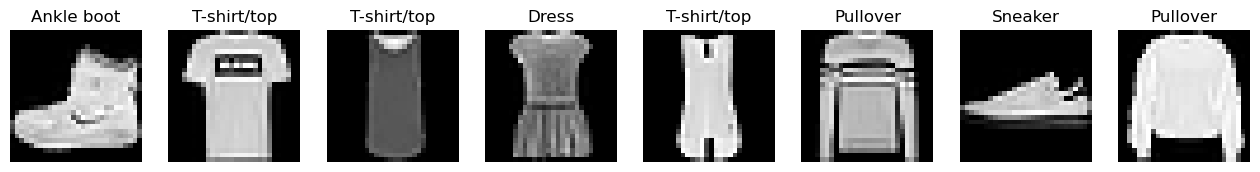

In [4]:
# 2. 학습 데이터에서 샘플 이미지 8개 출력

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    img, label = train_data[i]
    axes[i].imshow(img.view(28, 28), cmap="gray")
    axes[i].set_title(label_names[label])
    axes[i].axis("off")
plt.show()


자 위 코드는 훈련 데이터의 처음 8개를 간단히 시각화 해 본 것입니다. 보다시피 저해상도 흑백 사진으로 여러 의류가 들어있습니다. 우리 목표는 컴퓨터가 사진을 받아서 해당 사진이 10개의 범주 중 어디에 해당하는지 잘 분류하도록 학습하는 것입니다.

이걸 우리는 시각적으로 인지하지만 컴퓨터는 그걸 못하죠. 눈이 없거든요 ㅎㅎ 그래서 기본적으로 이걸 다루려면 뭔가 컴퓨터가 이해할 수 있는 방식으로 변환을 해줘야 합니다. 일단 이미지가 컴퓨터에 저장될 때에는 기본적으로 행렬로 저장됩니다. 이건 흑백이고, 28x28 해상도를 가져서 28x28 행렬 하나로 저장이 됩니다. 즉 전체 이미지를 748개의 구간으로 나눠서 각 구간의 흑백 이미지가 뭔지 표시하고 있는거죠. 예를 들어 '3번째 행 16번째 줄은 회색으로 표시해라' 같은 메시지가 숫자로 표현되고 있는 것입니다. 흑백 이미지는 0과 255 사이의 숫자로 표현이 되거든요 (0은 완전 검은색, 255는 완전 하얀색입니다) 여담이지만 컬리 이미지일 경우에는 RGB 세 색깔의 조합이 필요하기에 행렬 세 개가 필요합니다. 그리고 행렬의 크기는 해상도가 결정하고요. 

지금 첫 번째 셀의 코드에서 보면 x라는 데이터가 들어오면 x.view(-1)라는 명령을 거치게 되어 있음을 알 수 있습니다. 이건 데이터를 1차원으로 펼치는 역할을 합니다. 즉 이 경우에는 28x28 행렬이 1x784 라는 그냥 벡터로 변환되는 것이지요. 각 이미지를 이렇게 1차원 벡터로 변환시켜서 입력으로 넣고, 그것이 각 범주와 연결되는 패턴을 찾으려고 하는 것입니다. 

자 이제 데이터라는 재료가 있으니, 학습의 대상이 되는 신경망 모델을 만들어야 합니다. 그건 아래와 같이 만듭니다. 

In [5]:
# 3. MLP 모델 정의
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)   # 입력 784 → 은닉층 128
        self.fc2 = nn.Linear(128, 10)    # 은닉층 128 → 출력 10클래스

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)  # 마지막 softmax는 CrossEntropyLoss가 처리
        return x

model = SimpleMLP()


이게 뭔가 싶으실 것입니다. 간단히 설명드리면 이렇습니다. 
- 파이토치는 신경망을 만드는 클래스를 미리 규정해두고 있습니다. 그걸 nn.Module로 접근할 수 있습니다. 
- 이건 기본적으로 클래스라서, attribute (속성)과 method (방법)을 설정해줘야 합니다. 클래스는 파이썬 같은 객체지향언어의 특징을 잘 보여주는 도구인데, 어떤 프로그램이 다룰 수 있는 재료와 방법을 묶음으로 정의해서 운용하는 방식입니다. 
- 잘 이해가 되지 않을 수도 있겠다 싶고, 지금은 꼭 이해하지 않으셔도 됩니다. 다만 여기서는 속성 파트에 신경망을 이루는 각종 레이어를 설정하고, 방법 파트에서 forward라는 함수를 필수적으로 만들어서 신경망 모델의 '순전파'가 어떻게 이뤄지는지 표시해둬야 합니다 
- 예를 들어 위에서는 fc1라는 속성을 만드는데, 그게 linear layer이며, 길이 784인 벡터 형식의 입력을 받아 길이 128인 벡터로 변환하는 역할을 하고 있습니다. 즉 입력 데이터가 784개의 숫자를 가지고 있는데, 그걸 128개로 줄이는거죠. 그리고 각 128개의 숫자는 784개의 숫자에 모두 가중치가 곱해지고 더해져서 생깁니다. 즉 이건 입력 데이터에 (784x128)이라는 행렬을 곱해주는 효과를 냅니다.
- fc2는 또 다른 linear layer를 설정한 것입니다. 이건 길이 128 벡터 데이터를 길이 10인 벡터로 줄이는 효과를 내내요. 짐작하다시피, 10은 우리가 예측해야 하는 결과 범주의 개수입니다. 각 데이터에서 10개의 수치가 산출될텐데, 그게 10개의 범주 중 어디에 해당하는지를 표현하는 가중치가 되겠죠. 
- fc라는 이름은 fully connected layer의 준말입니다. 신경망 모델을 공부하다보면 여러 종류의 layer가 존재함을 알게 되실텐데, 가장 기본적인 층이 '완전 연결층'입니다. 
- forward에서는 데이터가 들어와서 어떻게 흘러가는지 표현합니다. 지금은 x가 들어오면 fc1으로 설정된 첫번째 linear layer를 통과한 후, relu 활성화 함수를 거치고, 그 다음 fc2라는 linear layer를 거쳐 결과가 나오게 됩니다. 우리가 배운대로라면 여기서 softmax가 들어가야 하는데, 파이토치는 이 기능을 nn.CrossEntropyLoss 라는 손실을 계산하는 클래스가 담당하도록 설계해뒀습니다. 그래서 이대로 출력하는거죠. 
- forward 이외에 메서드를 더 넣어도 괜찮습니다. 일종의 help function을 설정할 수도 있지요. forward라는 함수가 필수적으로 있어야 하고, 그 안에는 신경망 순전파 경로가 있어야 한다는 점만 지키면 됩니다. 

자 우리가 간단히 만들어 본 model을 설정했습니다. 다음은 뭘까요? 학습 알고리즘을 세팅해야겠죠. 우리가 배운바에 따르면 이를 위해서는 손실을 계산하는 방법을 설정해야 하고, 미분계수를 활용하여 구체적으로 어떻게 업데이트할지 결정해야 합니다. 그걸 바로 다음에 하고 있습니다. 

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


자 여기서 우리는 두 가지를 설정합니다. 
1) 손실을 어떻게 계산할 것인가? -> 이 파트가 criterion = nn.CrossEntropyLoss() 라는 명령으로 표현되고 있습니다. 크로스 엔트로피 로스로 하겠다는 거죠. 앞서 봤듯이, 범주형 문제에서 흔히 사용되는 방식입니다. 그리고 nn.CrossEntropyLoss() 라는 클래스는 입력이 들어오면 거기에 소프트 맥스를 거는 것까지 포함하고 있습니다. 
2) 손실이 각 파라미터에 대해 가지는 그레디언트를 가지고 어떻게 파라미터를 업데이트할 것인가? -> 이 파트가 optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 라는 부분을 통해 구현되고 있습니다. 지금 Adam을 쓸 것이고, 거기서 학습률은 0.003 으로 하겠다고 말하고 있는거죠. 이외에도 설정해줘야 할 것이 있지만 왠만하면 디폴트 값을 쓰는게 일반적입니다. https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html 이런 링크를 참조하시면 됩니다. 

역전파 알고리즘은? 이라고 생각하시겠죠. 파이토치 같은 딥러닝 프레임 워크가 좋은 것이, 이게 그냥 텐서, 즉 파이토치가 운용하는 기본 자료 구조 수준에서 자동으로 다 그레디언트 계산을 수행을 합니다. 이건 당연히 하는거라 유저가 건드리지 않아도 되도록 하고 있습니다. (물론 건드리는 방법도 있습니다) 

그럼 이제 자료 있고, 모델 있고, 손실 계산법 있고, 최적화 알고리즘 설정했고, 그레디언트는 다 계산됩니다. 그러면 뭘 해야 하나요? 학습하는 흐름을 for 구문 등을 통해 짜줍니다. 아래 같은 코드가 전형적입니다. 한 번 실행해보고 구조를 살펴봅시다. 


In [7]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()   # 역전파
        optimizer.step()  # 파라미터 업데이트

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/5, Loss: 0.5451
Epoch 2/5, Loss: 0.3973
Epoch 3/5, Loss: 0.3552
Epoch 4/5, Loss: 0.3303
Epoch 5/5, Loss: 0.3114


좀 느릴 것입니다. gpu를 사용하도록 설정해주면 훨씬 빨리되는데, 대부분 랩탑에는 그게 없을 듯해서 그냥 구성했습니다. 자 간단한 이중 for 구문인데요. 맨 바깥 for는 전체 데이터를 다섯 번 학습시키라는 명령을 하고 있죠. 그래서 그걸 epoch이라는 변수명으로 제어하고 있습니다. 그럼 에폭 한 번에는 뭘 하고 있나요?

- 우선 로스를 초기화합니다. 
- 그런 다음 train_loader라는 것에서 x와 y를 하나씩 빼옵니다. 이게 dataloader였습니다. 즉 하나의 배치로 묶인 데이터를 순차적으로 꺼내고 있습니다. x는 이미지 자체 (1차원 벡터로 변환된), y는 레이블/정답입니다. 모든 데이터가 소진될 때까지 아래의 과정을 반복합니다. 
- x와 y, 즉 각 배치 데이터를 가져와서, model에 x를 넣고 예측치인 preds를 만듭니다. 그 다음 preds와 y를 비교해서 손실을 계산합니다. 
- 그 손실에 근거하여 역전파 알고리즘을 통해 그레디언트를 계산합니다. 
- 그 그레디언트를 활용하여 우리가 설정한 최적화 알고리즘을 통해 파라미터를 업데이트합니다. (두 번째 for 구문 맨 윗줄에 이 최적화 알고리즘 클래스가 초기화 되는 파트가 있습니다. 이건, 매 배치마다 새로 그레디언트가 계산되고 그것에 근거하여 업데이트가 되어야 해서 깨끗이 비우는 절차입니다)

이걸 여러번 반복하면 훈련이 되는 것이죠. 실제로 지금쯤이면 끝났을 위 셀 출력창을 보시면, loss가 줄어드는 것을 보실 수 있습니다. 

여담이지만, 이 정도면 엄청나게 간단하게 신경망 모델의 세팅과 훈련을 하는 것입니다. 위에서 지금 장장 30페이지 넘게 펼쳐진 설명을 10줄 이내의 코드로 구현해버린 것이잖아요? 조금만 익숙해지시면 엄청 간단하다는 것을 아실 수 있습니다. 

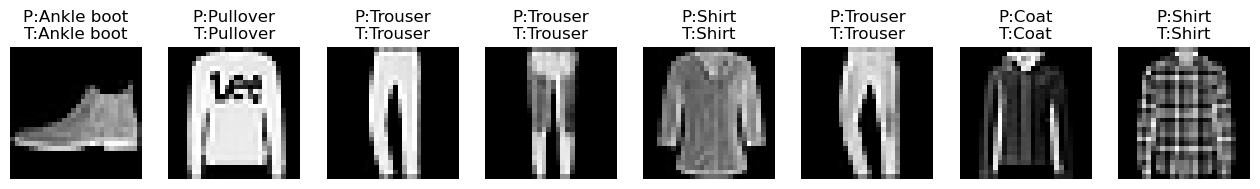

In [8]:
# 6. 테스트 이미지 8개에서 예측 vs 실제 시각화

model.eval()
fig, axes = plt.subplots(1, 8, figsize=(16, 3))

with torch.no_grad():
    for i in range(8):
        img, label = test_data[i]
        pred = model(img).argmax().item()
        
        axes[i].imshow(img.view(28, 28), cmap="gray")
        axes[i].set_title(f"P:{label_names[pred]}\nT:{label_names[label]}")
        axes[i].axis("off")

plt.show()


테스트 데이터에 있는 첫 8개 이미지를 우리의 학습된 모델이 어떻게 예측하는지 한 번 살펴봤습니다. 전부 다 정확하게 맞췄네요. 제법 학습이 잘 된 모양입니다. 10000개에서 보여주는 퍼포먼스는 어떤지 살펴봅시다. 

In [9]:
correct = 0
total = 0
model.eval()

with torch.no_grad():
    for x, y in test_loader:
        preds = model(x)
        predicted = preds.argmax(dim=1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

print(f"Test Accuracy: {correct/total:.4f}")


Test Accuracy: 0.8734


제 결과에서는 정확도가 87.3%가 나오네요. 여러분도 85%-88%에서 결과가 나왔을 것이라 짐작합니다. 꽤 괜찮죠? CNN 등을 사용하면 더 높은 정확도를 얻을 수 있습니다. 이러니까 사람들이 딥러닝 딥러닝 하는거죠^^

휴 길었습니다. 텍스트 분석하려다가 신경망을 너무 오래 설명했네요. 다음 시간부터는 다시 텍스트로 돌아갑시다. 신경망이 텍스트 데이터도 기가 막히게 잘 다루거든요!!